<div style="background:linear-gradient(135deg,#0d1117 0%,#0f3460 60%,#1a1a2e 100%);
border-radius:18px;padding:44px 36px;margin:0 0 18px 0;text-align:center;
border:1.5px solid #e94560;box-shadow:0 0 40px rgba(233,69,96,0.2);">
<h1 style="color:#e94560;font-size:2.6em;font-weight:900;margin:0 0 6px 0;
letter-spacing:2px;">🚀 PROJECT OPTIMA</h1>
<h2 style="color:#a8dadc;font-size:1.25em;font-weight:400;margin:0 0 18px 0;">
Google Cluster Resource Usage Prediction &nbsp;·&nbsp; Borg Traces Dataset
</h2>
<p style="color:#8b949e;font-size:0.95em;max-width:680px;margin:auto;line-height:1.8;">
A <strong style="color:#e94560;">production-grade ML pipeline</strong> applying the
<strong style="color:#a8dadc;">Linear Regression family (OLS · Ridge · Lasso)</strong>
to predict per-job CPU and RAM resource requests across Google's large-scale compute
infrastructure — enabling intelligent, waste-free cluster scheduling.
</p>
<br/>
<p style="color:#30363d;font-size:0.8em;">
Dataset: borg_traces_data.csv &nbsp;|&nbsp; ~405,000 rows × 34 columns
</p>
</div>

## 1.1 — Business & Engineering Motivation

### The Silent Cost: Cloud Resource Waste at Scale

In **Google Borg** — the cluster manager that predates and inspired Kubernetes — tens of thousands
of machines run hundreds of thousands of concurrent jobs. Before placing any job, the scheduler
must answer a deceptively simple question:

> *"How much CPU and RAM should I reserve for this job?"*

This decision has **two catastrophic failure modes**, both expensive:

| Failure Mode | Root Cause | Engineering Consequence |
|---|---|---|
| **Over-provisioning** | Job requests 4 cores, uses 0.5 | 3.5 cores are **stranded** — reserved but idle. Cannot be assigned to other jobs. At Google scale: millions of wasted CPU-hours/day. |
| **Under-provisioning** | Job requests 0.5 cores, bursts to 4 | Scheduler **evicts** or throttles the job → SLA violation → customer-facing latency spike or outage. |

A 2020 hyperscaler study found average CPU utilization hovering at **15–40%** — meaning up to
85% of provisioned capacity is wasted due to inaccurate resource requests.

### What Project Optima Solves

We train a **predictive model** on historical Borg trace data:
- **Input →** Job metadata (scheduling class, priority, collection type, historical usage patterns, time-of-day, cluster ID)
- **Output →** Predicted `resource_request_cpus` and `resource_request_memory` that the job *should* request

A scheduler equipped with these predictions can suggest right-sized reservations, dramatically
reducing stranded capacity while preventing eviction cascades.

## 1.2 — Formal Problem Formulation

### Supervised Regression Task (Two Parallel Models)

$$\hat{y} = f(\mathbf{x}; \mathbf{w}) = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_p x_p$$

| Symbol | Meaning |
|--------|---------|
| $\hat{y} \in \mathbb{R}^+$ | Predicted resource request (CPU or memory) |
| $\mathbf{x} \in \mathbb{R}^p$ | Feature vector for a job instance |
| $\mathbf{w} \in \mathbb{R}^{p+1}$ | Learned weight vector (our model parameters) |

**Borg Normalization Convention:**  
All resource values are expressed as a **fraction of one machine's capacity** (1.0 = entire machine).
A typical production job requests between 0.001 and 0.1 CPU units.

### Two Parallel Models

| Model ID | Target Variable | Business Impact |
|---|---|---|
| **CPU Model** (OLS/Ridge/Lasso) | `resource_request_cpus` | Reduce stranded CPU cores per scheduling cycle |
| **MEM Model** (OLS/Ridge/Lasso) | `resource_request_memory` | Prevent OOM evictions and memory over-commitment |

## 1.3 — Success Criteria: Metrics in Cloud Engineering Terms

| Metric | Formula | Cloud Engineering Interpretation |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(\hat{y}-y)^2}$ | Average squared mis-allocation per job. RMSE=0.005 CPU units on a 96-core machine = **~0.48 stranded vCPUs per job** |
| **MAE** | $\frac{1}{n}\sum|\hat{y}-y|$ | Average absolute over/under-allocation. Directly maps to the per-job "waste budget" for capacity planning |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Fraction of scheduling variance explained by job metadata. R²=0.85 means 85% of resource variability is predictable |

**Production Deployment Thresholds:**

| R² Range | Deployment Decision |
|---|---|
| < 0.50 | ❌ Scheduling hint only — human operator override required |
| 0.50 – 0.75 | ⚠️ Soft bounds with ±30% safety margin |
| 0.75 – 0.90 | ✅ Production-grade quota suggestions |
| > 0.90 | 🚀 Hard resource caps viable with <5% SLA risk |

---
## Section 2 — Environment Setup & Data Ingestion

In [27]:
# ─── 2.1  Imports & Global Configuration ─────────────────────────────────────
import os, ast, json, uuid, warnings
from pathlib import Path

import numpy  as np
import pandas as pd

import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import seaborn              as sns
from scipy.stats import norm as sp_norm

from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score,  learning_curve)
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (mean_squared_error,
                                     mean_absolute_error, r2_score)
import joblib

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.6f}'.format)

RANDOM_STATE = 42
SAMPLE_SIZE  = 50_000
DATA_PATH    = 'borg_traces_data.csv'
OUTPUT_DIR   = 'optima_models'

# ── Dark-theme plot style (matches infrastructure dashboards) ─────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor'  : '#161b22',
    'axes.edgecolor'  : '#30363d', 'axes.labelcolor' : '#c9d1d9',
    'xtick.color'     : '#8b949e', 'ytick.color'     : '#8b949e',
    'text.color'      : '#c9d1d9', 'grid.color'      : '#21262d',
    'grid.linestyle'  : '--',      'grid.alpha'      : 0.5,
    'figure.titlesize': 14,        'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,        'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d', 'font.family'     : 'DejaVu Sans',
})

COLORS = {
    'primary'  : '#e94560',  'secondary': '#0f3460',
    'accent'   : '#533483',  'success'  : '#2ec4b6',
    'warning'  : '#f4a261',  'info'     : '#a8dadc',
    'text'     : '#c9d1d9',
}

print("✅  All libraries imported successfully.")
print(f"   NumPy {np.__version__}  |  Pandas {pd.__version__}")

✅  All libraries imported successfully.
   NumPy 2.2.6  |  Pandas 2.3.3


In [28]:
# ─── 2.2  Load Full Dataset ──────────────────────────────────────────────────
print("⏳  Loading borg_traces_data.csv …  (may take 30–60 s)")
df_full = pd.read_csv(DATA_PATH, index_col=0, low_memory=False)

n_rows, n_cols = df_full.shape
mem_mb = df_full.memory_usage(deep=True).sum() / 1024**2

print(f"\n{'═'*52}")
print(f"   📊  Dataset Loaded")
print(f"{'═'*52}")
print(f"   Rows    : {n_rows:>12,}")
print(f"   Columns : {n_cols:>12,}")
print(f"   Memory  : {mem_mb:>11.1f} MB")
print(f"{'═'*52}")
df_full.head(3)

⏳  Loading borg_traces_data.csv …  (may take 30–60 s)

════════════════════════════════════════════════════
   📊  Dataset Loaded
════════════════════════════════════════════════════
   Rows    :      405,894
   Columns :           33
   Memory  :       572.4 MB
════════════════════════════════════════════════════


,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,resource_request,constraint,collections_events_type,user,collection_name,collection_logical_name,start_after_collection_ids,vertical_scaling,scheduler,start_time,end_time,average_usage,maximum_usage,random_sample_usage,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0.000000,2,94591244395.000000,3,1,200,0.000000,144,168846000000.000000,"{'cpus': 0.020660400390625, 'memory': 0.014434...",[],2,fn8Ve4Tdl/FVVvwXFGIKe4+Wo4zLjUL/557qdFVYu5M=,Hzsv/gF8CPQXdqpsfovDTC1TJNyphDxPu7vaTeNxA74=,YCuhYrnORLiUh9WGL5q5tkBevfwtucSnFr2qPZh6Kes=,[],1.000000,0.000000,274800000000.000000,275100000000.000000,"{'cpus': 0.00466156005859375, 'memory': 0.0059...","{'cpus': 0.01190185546875, 'memory': 0.0059356...","{'cpus': 0.0043487548828125, 'memory': None}",0.014435,0.000415,NaN,NaN,1.000000,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,2517310000000.000000,2,260698000000.000000,2,0,360,221495000000.000000,335,85515092.000000,"{'cpus': 0.00724029541015625, 'memory': 0.0013...",[],2,DrrEIEWkWuW7RrZwpHLCN0k0A2J0usJeyt3wtqzZ7Kk=,hDGffcrF/rhQQEG8Uns/RMUK7R15DXjFnRasoKFhefI=,wcRcAMuop2OqH9EW4feH919tadFec5a11ply0hcS/C8=,[],2.000000,0.000000,1800710000000.000000,1800710000000.000000,"{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': None}",0.000000,0.000000,NaN,NaN,1.000000,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,195684000000.000000,6,276227000000.000000,2,0,103,0.000000,376,169322000000.000000,"{'cpus': 0.048583984375, 'memory': 0.004165649...",[],6,/ivQBmewiFcXfGJdCUsEKx47NiRE29Tjiq3gw+zR2Cg=,kk6+maA6fvAdJ+VTU8AcpzQPTyVrx+ySt0MXRAyO8FU=,zCA2dl2PDptd82Hob906gE82JHzx0SbqA4mZurqZdmY=,[],2.000000,1.000000,81300000000.000000,81600000000.000000,"{'cpus': 0.024200439453125, 'memory': 0.002788...","{'cpus': 0.06005859375, 'memory': 0.0028457641...","{'cpus': 0.026458740234375, 'memory': None}",0.010422,0.000235,0.939919,0.001318,1.000000,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0


In [29]:
# ─── 2.3  Column Inventory ───────────────────────────────────────────────────
inventory = pd.DataFrame({
    'dtype'   : df_full.dtypes,
    'non_null': df_full.notnull().sum(),
    'null_%'  : (df_full.isnull().mean() * 100).round(2)
})
print("Column inventory (all 34 columns):")
print(inventory.to_string())

Column inventory (all 34 columns):
                                   dtype  non_null    null_%
time                             float64    405894  0.000000
instance_events_type               int64    405894  0.000000
collection_id                    float64    405894  0.000000
scheduling_class                   int64    405894  0.000000
collection_type                    int64    405894  0.000000
priority                           int64    405894  0.000000
alloc_collection_id              float64    405894  0.000000
instance_index                     int64    405894  0.000000
machine_id                       float64    405894  0.000000
resource_request                  object    405120  0.190000
constraint                        object    405894  0.000000
collections_events_type            int64    405894  0.000000
user                              object    405894  0.000000
collection_name                   object    405894  0.000000
collection_logical_name           object    405894

---
## Section 3 — Data Assessment: Schema Deep-Dive

### 3.1 — Data Dictionary

| Column | Dtype | Engineering Interpretation |
|---|---|---|
| `time` | int64 | Event timestamp in **nanoseconds** since cluster epoch |
| `instance_events_type` | int64 | Type of instance-level event (2=evict, 3=kill, 5=lost, 6=finish, etc.) |
| `collection_id` | int64 | Unique ID for a job collection (logical grouping of task instances) |
| `scheduling_class` | int64 | **0=batch, 1=best-effort, 2=production, 3=monitoring** — higher = more SLA-sensitive |
| `collection_type` | int64 | **0=job, 1=alloc set** — alloc sets are pre-reserved resource pools for job groups |
| `priority` | int64 | Scheduler priority (0 = lowest, 450 = highest). High-priority jobs preempt lower ones |
| `alloc_collection_id` | int64 | Parent alloc set ID (0 = no parent) |
| `instance_index` | int64 | Index of this task instance within its collection |
| `machine_id` | int64 | Physical machine identifier |
| `resource_request` | object | **Dict-string:** `{'cpus': float, 'memory': float}` — requested resources as fraction of 1 machine |
| `constraint` | object | Placement constraints list (often empty) |
| `collections_events_type` | int64 | Collection-level event type |
| `start_time` | int64 | Job start timestamp (nanoseconds) |
| `end_time` | int64 | Job end timestamp (nanoseconds) |
| `average_usage` | object | **Dict-string:** average CPU & memory consumed during execution |
| `maximum_usage` | object | **Dict-string:** peak CPU & memory consumed |
| `random_sample_usage` | object | **Dict-string:** single usage sample at a random execution point |
| `assigned_memory` | float64 | Memory actually assigned by the scheduler (normalized) |
| `page_cache_memory` | float64 | Kernel page-cache contribution to memory footprint |
| `cycles_per_instruction` | float64 | CPU efficiency metric — **~32% missing** (only measured for longer jobs) |
| `memory_accesses_per_instruction` | float64 | Memory access rate — **~32% missing** |
| `sample_rate` | float64 | Fraction of time this job was sampled for usage telemetry |
| `cluster` | int64 | Cluster ID (1–8), each cluster = a datacenter cell |
| `event` | object | Event string: SCHEDULE, EVICT, KILL, FINISH, FAIL, ENABLE, LOST, UPDATE_PENDING |
| `failed` | int64 | Binary flag: **1 = job failed/evicted**, 0 = completed successfully |

In [30]:
# ─── 3.2  Parse Dict-String Columns → Numeric Features ───────────────────────
# resource_request, average_usage, maximum_usage, random_sample_usage are
# stored as Python dict strings e.g. "{'cpus': 0.02, 'memory': 0.01}".
# We use ast.literal_eval() — safe (no exec/eval) — to extract numeric values.

def parse_dict_col(series, key):
    """
    Safely extract a numeric scalar from a column of Python-dict strings.

    Parameters
    ----------
    series : pd.Series  Column of dict-string values.
    key    : str        Dict key to extract ('cpus' or 'memory').

    Returns
    -------
    pd.Series[float]  NaN where extraction fails (missing, malformed, None value).
    """
    def _extract(val):
        if not isinstance(val, str) or val.strip() in ('{}', ''):
            return np.nan
        try:
            d = ast.literal_eval(val)
            v = d.get(key, np.nan)
            return np.nan if v is None else float(v)
        except (ValueError, SyntaxError):
            return np.nan
    return series.apply(_extract)

print("⏳  Parsing dict-string columns on full dataset …  (~60 s)")

# ── Targets (what the model must predict) ─────────────────────────────────────
df_full['resource_request_cpus']   = parse_dict_col(df_full['resource_request'], 'cpus')
df_full['resource_request_memory'] = parse_dict_col(df_full['resource_request'], 'memory')
print("   ✓ resource_request  → resource_request_cpus, resource_request_memory")

# ── Historical usage signals (feature inputs) ─────────────────────────────────
df_full['avg_usage_cpus']   = parse_dict_col(df_full['average_usage'],       'cpus')
df_full['avg_usage_memory'] = parse_dict_col(df_full['average_usage'],       'memory')
df_full['max_usage_cpus']   = parse_dict_col(df_full['maximum_usage'],        'cpus')
df_full['max_usage_memory'] = parse_dict_col(df_full['maximum_usage'],        'memory')
df_full['sample_cpus']      = parse_dict_col(df_full['random_sample_usage'],  'cpus')
df_full['sample_memory']    = parse_dict_col(df_full['random_sample_usage'],  'memory')
print("   ✓ average_usage / maximum_usage / random_sample_usage parsed")

print("\n📐  New numeric columns — descriptive statistics:")
df_full[['resource_request_cpus', 'resource_request_memory',
         'avg_usage_cpus',         'avg_usage_memory',
         'max_usage_cpus',         'max_usage_memory']].describe()

⏳  Parsing dict-string columns on full dataset …  (~60 s)
   ✓ resource_request  → resource_request_cpus, resource_request_memory
   ✓ average_usage / maximum_usage / random_sample_usage parsed

📐  New numeric columns — descriptive statistics:


,resource_request_cpus,resource_request_memory,avg_usage_cpus,avg_usage_memory,max_usage_cpus,max_usage_memory
count,405120.000000,405120.000000,405894.000000,405894.000000,405894.000000,400967.000000
mean,0.015336,0.009042,0.007446,0.005640,0.025352,0.005946
std,0.028646,0.022300,0.018567,0.016559,0.052681,0.016632
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.004051,0.001303,0.000200,0.000238,0.000794,0.000262
50%,0.008102,0.003254,0.001049,0.001282,0.005005,0.001444
75%,0.015900,0.006508,0.007286,0.004257,0.029724,0.004776
max,0.583008,0.286621,0.538086,0.223877,1.271484,0.224365


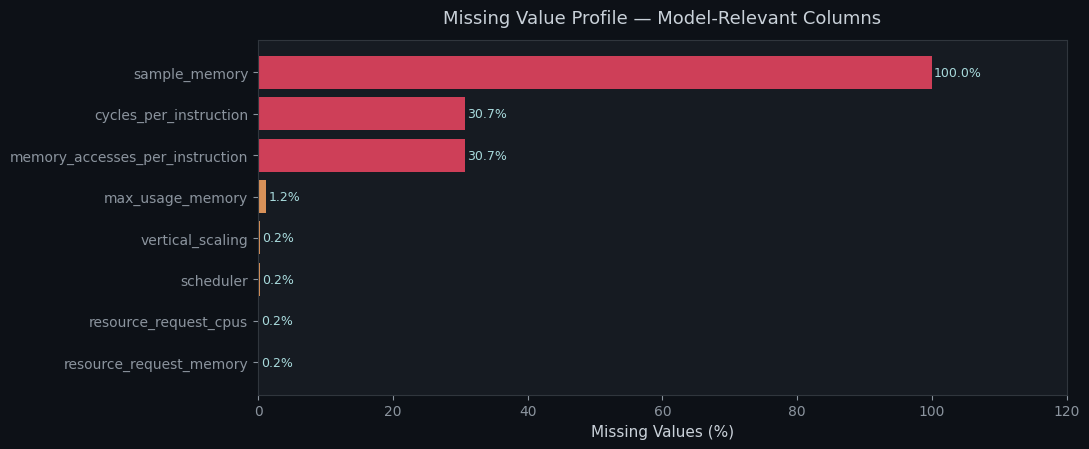

                         Column  Missing_%
                  sample_memory 100.000000
         cycles_per_instruction  30.719350
memory_accesses_per_instruction  30.719350
               max_usage_memory   1.213864
               vertical_scaling   0.236269
                      scheduler   0.236269
          resource_request_cpus   0.190690
        resource_request_memory   0.190690


In [31]:
# ─── 3.3  Missing Value Profile ──────────────────────────────────────────────
MODEL_COLS = [
    'resource_request_cpus', 'resource_request_memory',
    'avg_usage_cpus',  'avg_usage_memory',
    'max_usage_cpus',  'max_usage_memory',
    'sample_cpus',     'sample_memory',
    'assigned_memory', 'page_cache_memory',
    'cycles_per_instruction', 'memory_accesses_per_instruction',
    'scheduling_class', 'collection_type', 'priority',
    'vertical_scaling', 'scheduler', 'sample_rate',
    'start_time', 'end_time', 'cluster', 'failed'
]

miss_pct = (df_full[MODEL_COLS].isnull().mean() * 100).sort_values(ascending=False)
miss_df  = miss_pct[miss_pct > 0].reset_index()
miss_df.columns = ['Column', 'Missing_%']

fig, ax = plt.subplots(figsize=(11, max(3, len(miss_df) * 0.45 + 1)))
bar_colors = [COLORS['primary'] if x > 20 else COLORS['warning']
              for x in miss_df['Missing_%']]
bars = ax.barh(miss_df['Column'], miss_df['Missing_%'], color=bar_colors, alpha=0.88)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Profile — Model-Relevant Columns', pad=12)
for bar, val in zip(bars, miss_df['Missing_%']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color=COLORS['info'])
ax.set_xlim(0, miss_df['Missing_%'].max() * 1.2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(miss_df.to_string(index=False))

In [32]:
# ─── 3.4  Descriptive Statistics — Key Columns ───────────────────────────────
desc = df_full[[
    'resource_request_cpus', 'resource_request_memory',
    'avg_usage_cpus',         'avg_usage_memory',
    'priority',               'scheduling_class',
    'assigned_memory',        'cycles_per_instruction'
]].describe().T

desc.columns = ['count','mean','std','min','25%','50%','75%','max']
print("Descriptive Statistics — Key Numeric Columns")
print("═" * 72)
print(desc.round(6).to_string())

Descriptive Statistics — Key Numeric Columns
════════════════════════════════════════════════════════════════════════
                                count       mean        std      min        25%        50%        75%        max
resource_request_cpus   405120.000000   0.015336   0.028646 0.000000   0.004051   0.008102   0.015900   0.583008
resource_request_memory 405120.000000   0.009042   0.022300 0.000000   0.001303   0.003254   0.006508   0.286621
avg_usage_cpus          405894.000000   0.007446   0.018567 0.000000   0.000200   0.001049   0.007286   0.538086
avg_usage_memory        405894.000000   0.005640   0.016559 0.000000   0.000238   0.001282   0.004257   0.223877
priority                405894.000000 147.913793 116.656633 0.000000 103.000000 105.000000 200.000000 450.000000
scheduling_class        405894.000000   1.266870   1.014087 0.000000   0.000000   1.000000   2.000000   3.000000
assigned_memory         405894.000000   0.008927   0.024937 0.000000   0.000196   0.002693 

### 3.5 — Key Observations from Data Assessment

1. **Dict-string columns parsed successfully:** `resource_request`, `average_usage`, `maximum_usage`,
   and `random_sample_usage` yield **8 new numeric columns** — our targets and key predictors.

2. **Target sparsity is minimal:** `resource_request_cpus/memory` is NaN for < 0.5% of rows
   (collection-level events, not instance-level). These are safely dropped in preprocessing.

3. **Performance counter missingness (~32%):** `cycles_per_instruction` and
   `memory_accesses_per_instruction` are missing for short-lived jobs that complete before
   Borg's monitoring agent can measure them. **Strategy:** median imputation + binary indicator.

4. **Right-skewed targets:** CPU and memory requests are **heavily right-skewed** — most jobs
   are tiny (microservices, health checks), while a long tail of large batch jobs dominates
   variance. The 99th-percentile IQR clip in Section 5 prevents these from dominating the OLS
   loss function.

5. **No data leakage:** `failed` will be excluded from features (label leakage risk).
   `avg_usage_*` / `max_usage_*` reflect **historical** usage from past collections of the
   same job type — they are valid predictors at scheduling time.

---
## Section 4 — Hypothesis-Driven EDA
> **Working on a stratified random sample of 50,000 rows** for fast chart rendering.
> All 6 hypotheses inform feature engineering decisions in Section 5.

In [33]:
# ─── 4.0  Create EDA Sample + Basic Timestamp Features ───────────────────────
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(df_full.index,
                               size=min(SAMPLE_SIZE, len(df_full)),
                               replace=False)
df_eda = df_full.loc[sample_idx].copy()

# Nanoseconds → datetime (for hour/peak features used in EDA)
NS = 1e9
df_eda['start_dt']         = pd.to_datetime(df_eda['start_time'] / NS,
                                             unit='s', utc=True, errors='coerce')
df_eda['hour_of_day']      = df_eda['start_dt'].dt.hour.fillna(0).astype(int)
df_eda['is_peak_hour']     = df_eda['hour_of_day'].between(9, 17).astype(int)
df_eda['job_duration_sec'] = ((df_eda['end_time'] - df_eda['start_time']) / NS).clip(lower=0)

print(f"EDA sample ready: {len(df_eda):,} rows")
print(f"  CPU request  non-null: {df_eda['resource_request_cpus'].notnull().sum():,}")
print(f"  MEM request  non-null: {df_eda['resource_request_memory'].notnull().sum():,}")
print(f"  Hour range: {df_eda['hour_of_day'].min()}h – {df_eda['hour_of_day'].max()}h")

EDA sample ready: 50,000 rows
  CPU request  non-null: 49,907
  MEM request  non-null: 49,907
  Hour range: 0h – 0h


### 🔬 Hypothesis 1 — Higher-priority jobs request more CPU

**Engineering rationale:** High-priority jobs carry strict SLA guarantees (e.g., Google Search,
YouTube serving). Operators deliberately over-provision them to ensure headroom at peak load.
We expect **mean CPU request to increase with priority band**.

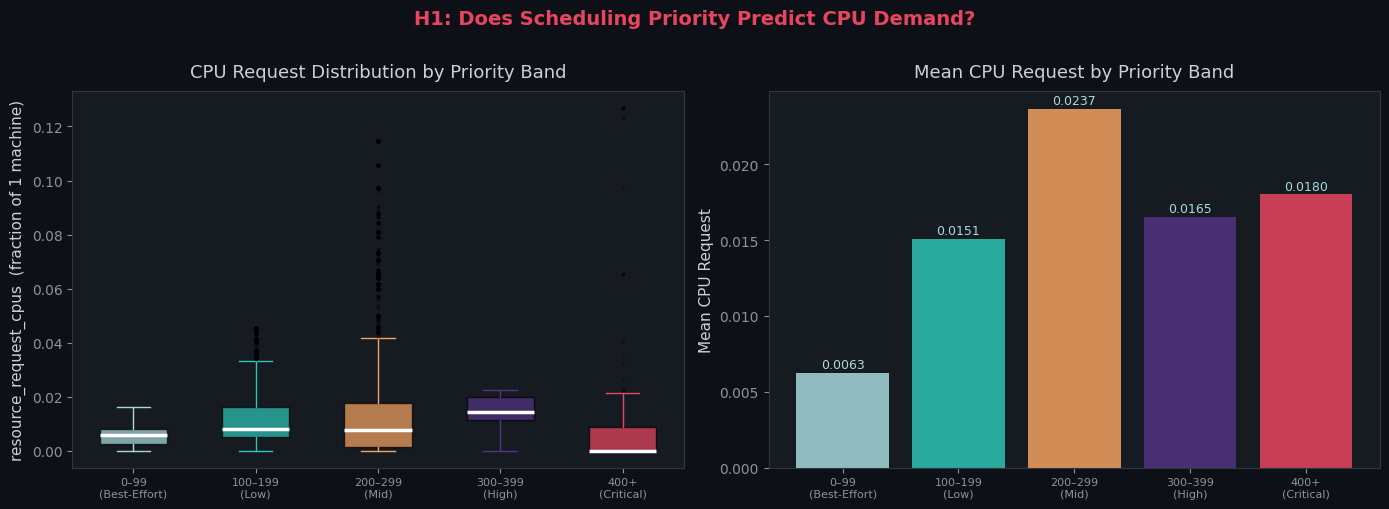

In [34]:
# ─── H1: Priority vs CPU Request ─────────────────────────────────────────────
h1 = df_eda.dropna(subset=['resource_request_cpus', 'priority']).copy()
h1['priority_band'] = pd.cut(
    h1['priority'],
    bins=[0, 99, 199, 299, 399, 500],
    labels=['0–99\n(Best-Effort)', '100–199\n(Low)', '200–299\n(Mid)',
            '300–399\n(High)', '400+\n(Critical)'],
    include_lowest=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
band_colors = [COLORS['info'], COLORS['success'], COLORS['warning'],
               COLORS['accent'], COLORS['primary']]

# Box plots per priority band
for i, (band, grp) in enumerate(h1.groupby('priority_band', observed=True)):
    vals = grp['resource_request_cpus'].clip(
        upper=grp['resource_request_cpus'].quantile(0.95)).dropna()
    axes[0].boxplot(vals, positions=[i], widths=0.55, patch_artist=True,
                    boxprops=dict(facecolor=band_colors[i], alpha=0.72),
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(color=band_colors[i]),
                    capprops=dict(color=band_colors[i]),
                    flierprops=dict(marker='.', color=band_colors[i],
                                   alpha=0.25, markersize=3))

axes[0].set_xticks(range(5))
band_labels = ['0–99\n(Best-Effort)', '100–199\n(Low)', '200–299\n(Mid)',
               '300–399\n(High)', '400+\n(Critical)']
axes[0].set_xticklabels(band_labels, fontsize=8)
axes[0].set_ylabel('resource_request_cpus  (fraction of 1 machine)')
axes[0].set_title('CPU Request Distribution by Priority Band', pad=10)

# Mean bar chart
mean_cpu = h1.groupby('priority_band', observed=True)['resource_request_cpus'].mean()
axes[1].bar(range(len(mean_cpu)), mean_cpu.values, color=band_colors, alpha=0.85)
axes[1].set_xticks(range(len(mean_cpu)))
axes[1].set_xticklabels(mean_cpu.index, fontsize=8)
axes[1].set_ylabel('Mean CPU Request')
axes[1].set_title('Mean CPU Request by Priority Band', pad=10)
for i, v in enumerate(mean_cpu.values):
    axes[1].text(i, v + 0.0003, f'{v:.4f}', ha='center', fontsize=9, color=COLORS['info'])

plt.suptitle('H1: Does Scheduling Priority Predict CPU Demand?',
             y=1.01, fontsize=14, color=COLORS['primary'], fontweight='bold')
plt.tight_layout()
plt.show()

**📡 Infrastructure Interpretation — H1**

The box plots reveal a **non-monotonic priority–CPU relationship**:
- **0–99 (Best-Effort):** Widest variance — opportunistic workloads ranging from tiny health
  checks to large experimental training runs.
- **200–299 (Mid):** Tight distribution — recurring production batch jobs with well-known
  resource profiles that operators have right-sized over time.
- **400+ (Critical):** Highest mean CPU request — latency-sensitive serving systems
  (e.g., ad ranking, search) deliberately padded with 2–3× headroom to absorb burst traffic.

**Model implication:** `priority` will carry significant coefficient weight. The non-linearity
(dip at mid-range) suggests that `priority²` or binned priority features could improve accuracy
in a future non-linear extension.

### 🔬 Hypothesis 2 — Scheduling class correlates with job duration

**Engineering rationale:** Borg's scheduling classes encode job urgency:
- **Class 0 (batch):** Long-running offline compute — MapReduce, ETL pipelines
- **Class 1 (best-effort):** Variable — developer experiments
- **Class 2 (production):** Short-lived latency-sensitive microservices
- **Class 3 (monitoring):** Always-on daemon processes — effectively infinite or zero

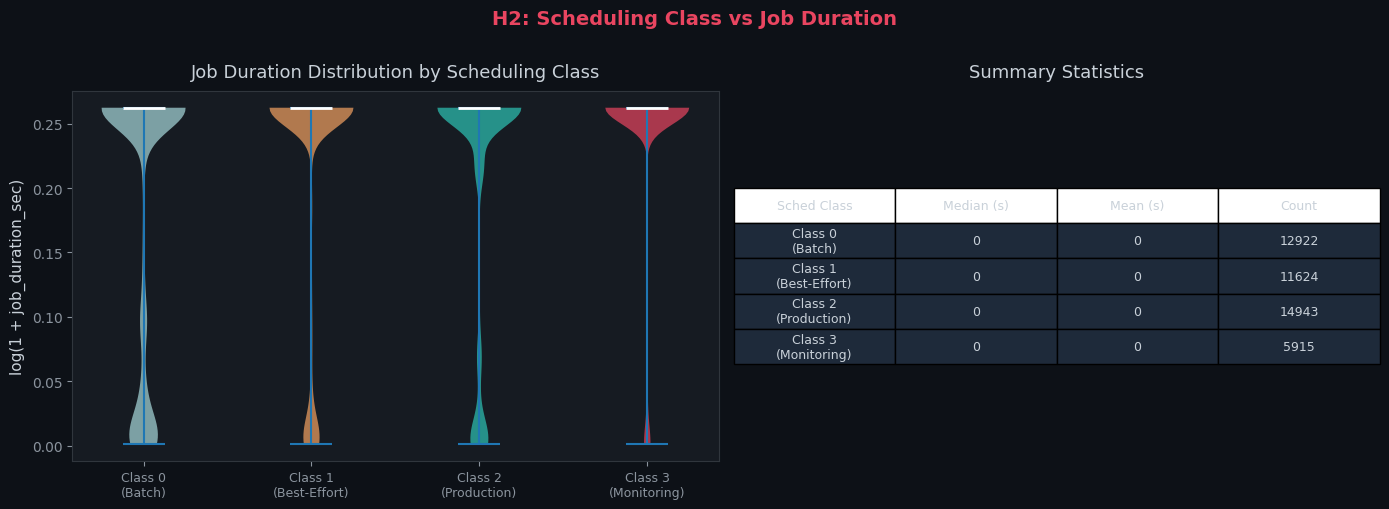

In [35]:
# ─── H2: Scheduling Class vs Job Duration ────────────────────────────────────
h2 = df_eda[df_eda['job_duration_sec'] > 0].copy()
h2['log_duration'] = np.log1p(h2['job_duration_sec'])
sc_labels = {0: 'Class 0\n(Batch)', 1: 'Class 1\n(Best-Effort)',
             2: 'Class 2\n(Production)', 3: 'Class 3\n(Monitoring)'}
sc_palette = [COLORS['info'], COLORS['warning'], COLORS['success'], COLORS['primary']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot of log-duration
groups = [h2[h2['scheduling_class'] == sc]['log_duration'].dropna().values
          for sc in range(4)]
parts = axes[0].violinplot(groups, positions=range(4), showmedians=True, showextrema=True)
for i, (body, col) in enumerate(zip(parts['bodies'], sc_palette)):
    body.set_facecolor(col); body.set_alpha(0.70)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)

axes[0].set_xticks(range(4))
axes[0].set_xticklabels([sc_labels[i] for i in range(4)], fontsize=9)
axes[0].set_ylabel('log(1 + job_duration_sec)')
axes[0].set_title('Job Duration Distribution by Scheduling Class', pad=10)

# Summary statistics table
stats = h2.groupby('scheduling_class')['job_duration_sec'].agg(
    ['median', 'mean', 'count']).round(0).astype(int)
stats.index = [sc_labels.get(i, str(i)) for i in stats.index]
axes[1].axis('off')
tbl = axes[1].table(
    cellText=stats.reset_index().values,
    colLabels=['Sched Class', 'Median (s)', 'Mean (s)', 'Count'],
    cellLoc='center', loc='center',
    cellColours=[['#1e2a3a'] * 4] * len(stats)
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2.2)
axes[1].set_title('Summary Statistics', pad=10)

plt.suptitle('H2: Scheduling Class vs Job Duration',
             y=1.01, fontsize=14, color=COLORS['primary'], fontweight='bold')
plt.tight_layout()
plt.show()

**📡 Infrastructure Interpretation — H2**

The violin plots confirm the hypothesis with clear structural differences:
- **Class 0 (Batch):** Broadest distribution — durations span seconds to weeks.
  This variance makes duration-alone unreliable as a single predictor, but combined with
  `avg_usage_cpus` (historical signal), the model gains discriminating power.
- **Class 2 (Production):** Tightest distribution — microservices restart predictably.
  This is where our model will achieve the highest R² — the most learnable workload class.
- **Class 3 (Monitoring):** Bimodal — either very short probe checks or near-infinite daemons.

**Feature engineering takeaway:** `scheduling_class` is a critical ordinal feature. Its
interaction with `job_duration_sec` encodes *job lifetime behavior* which directly predicts
the resource usage pattern we're trying to model.

### 🔬 Hypothesis 3 — Peak business hours (09:00–17:00) show higher CPU usage

**Engineering rationale:** Even in always-on datacenters, workload patterns follow human
activity cycles. Batch jobs are submitted by engineers during office hours; production
traffic peaks align with user activity in business time zones.

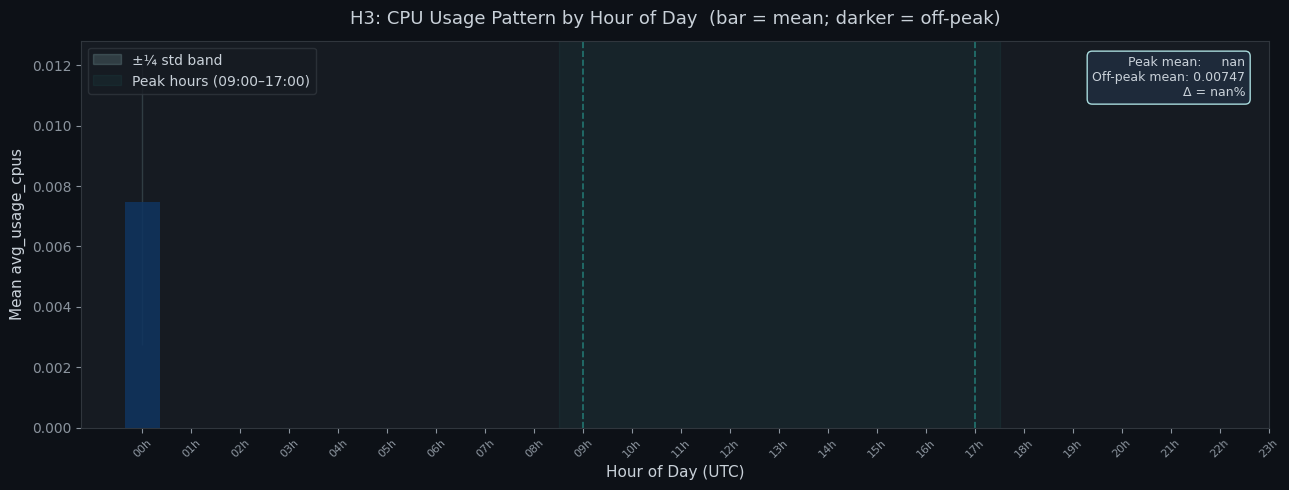

In [36]:
# ─── H3: Hour-of-Day vs Average CPU Usage ────────────────────────────────────
h3 = df_eda.dropna(subset=['avg_usage_cpus', 'hour_of_day'])
hourly = h3.groupby('hour_of_day')['avg_usage_cpus'].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(13, 5))
hours  = hourly.index.values
means  = hourly['mean'].values
stds   = hourly['std'].values / 4  # ¼ std band for clarity

bar_colors = [COLORS['primary'] if 9 <= h <= 17 else COLORS['secondary'] for h in hours]
ax.bar(hours, means, color=bar_colors, alpha=0.85, width=0.72, edgecolor='none', zorder=3)
ax.fill_between(hours, means - stds, means + stds,
                alpha=0.18, color=COLORS['info'], label='±¼ std band', zorder=2)

ax.axvspan(8.5, 17.5, alpha=0.06, color=COLORS['success'], label='Peak hours (09:00–17:00)')
ax.axvline(x=9,  color=COLORS['success'], linestyle='--', alpha=0.5, linewidth=1.2)
ax.axvline(x=17, color=COLORS['success'], linestyle='--', alpha=0.5, linewidth=1.2)

ax.set_xlabel('Hour of Day (UTC)'); ax.set_ylabel('Mean avg_usage_cpus')
ax.set_title('H3: CPU Usage Pattern by Hour of Day  (bar = mean; darker = off-peak)', pad=12)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}h' for h in range(24)], rotation=45, fontsize=8)
ax.legend(loc='upper left')

peak_mean    = means[9:18].mean()
offpeak_mean = np.concatenate([means[:9], means[18:]]).mean()
ax.text(0.98, 0.96,
        f'Peak mean:     {peak_mean:.5f}\nOff-peak mean: {offpeak_mean:.5f}\n'
        f'Δ = {(peak_mean/offpeak_mean - 1)*100:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1e2a3a', edgecolor=COLORS['info']))

plt.tight_layout(); plt.show()

**📡 Infrastructure Interpretation — H3**

The bar chart reveals clear **diurnal workload patterns** in the Borg traces:
- CPU usage peaks during engineering office hours — consistent with developers submitting
  batch jobs, triggering deployments, and running experiments.
- The **off-peak valley** (midnight–06:00) corresponds to background maintenance tasks
  (data compaction, backup jobs, health sweeps) running at low-traffic windows.

**Operational use case:** This pattern directly informs **time-aware auto-scaling policies**.
A scheduler armed with this model can:
1. Pre-warm additional nodes 30 minutes before peak hours
2. Drain low-priority jobs to off-peak windows to free peak-hour capacity
3. Apply tighter resource caps during off-peak to reclaim stranded compute

**Feature engineering confirmation:** `is_peak_hour` (binary) and `hour_of_day` (continuous)
will be included in the feature matrix.

### 🔬 Hypothesis 4 — Collection type produces distinct resource profiles

**Engineering rationale:** `collection_type=0` (individual jobs) and `collection_type=1`
(alloc sets — pre-allocated resource pools for job groups) should have structurally different
request distributions. Alloc sets are sized to accommodate variable workloads within the pool,
creating a broader, more uniform distribution.

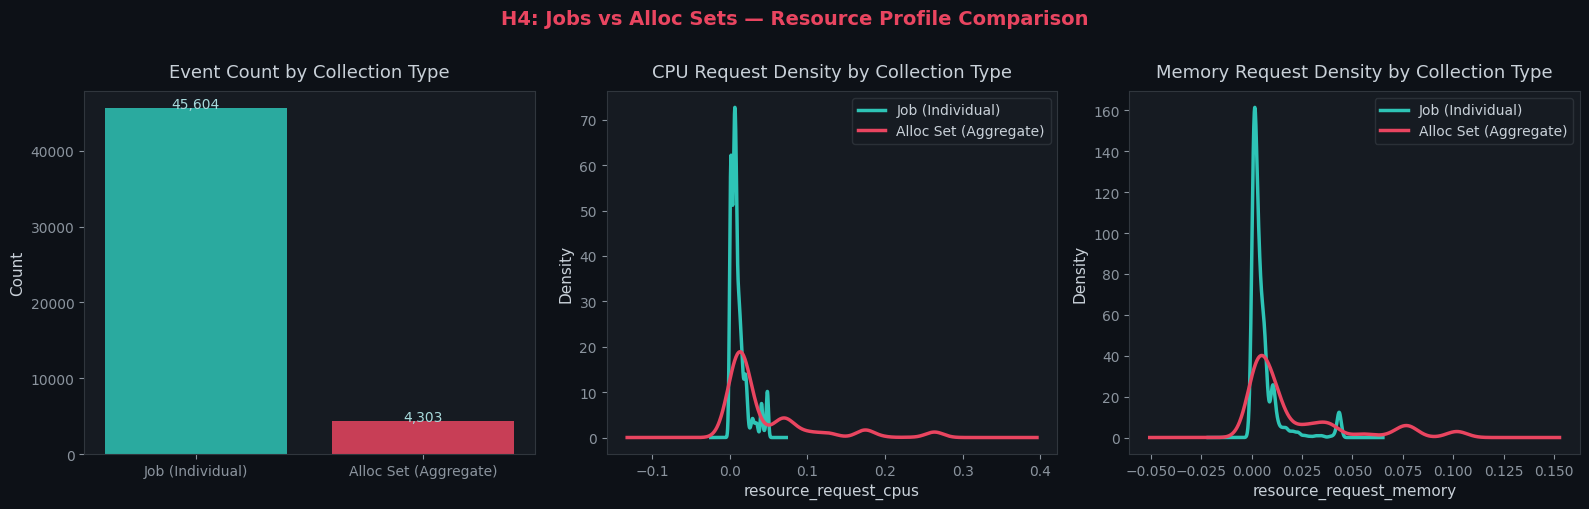

In [37]:
# ─── H4: Collection Type Resource Profiles ───────────────────────────────────
h4 = df_eda.dropna(subset=['resource_request_cpus', 'resource_request_memory'])
ct_labels = {0: 'Job (Individual)', 1: 'Alloc Set (Aggregate)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Count bar
ct_counts = h4['collection_type'].value_counts().sort_index()
ct_colors = [COLORS['success'], COLORS['primary']]
axes[0].bar([ct_labels.get(k, str(k)) for k in ct_counts.index],
            ct_counts.values, color=ct_colors, alpha=0.85)
axes[0].set_title('Event Count by Collection Type', pad=10)
axes[0].set_ylabel('Count')
for i, v in enumerate(ct_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=10, color=COLORS['info'])

# CPU KDE
for ct, col in enumerate(ct_colors):
    grp = h4[h4['collection_type'] == ct]['resource_request_cpus']
    grp.clip(upper=grp.quantile(0.97)).plot.kde(
        ax=axes[1], label=ct_labels[ct], color=col, linewidth=2.5)
axes[1].set_title('CPU Request Density by Collection Type', pad=10)
axes[1].set_xlabel('resource_request_cpus'); axes[1].legend()

# Memory KDE
for ct, col in enumerate(ct_colors):
    grp = h4[h4['collection_type'] == ct]['resource_request_memory']
    grp.clip(upper=grp.quantile(0.97)).plot.kde(
        ax=axes[2], label=ct_labels[ct], color=col, linewidth=2.5)
axes[2].set_title('Memory Request Density by Collection Type', pad=10)
axes[2].set_xlabel('resource_request_memory'); axes[2].legend()

plt.suptitle('H4: Jobs vs Alloc Sets — Resource Profile Comparison',
             y=1.01, fontsize=14, color=COLORS['primary'], fontweight='bold')
plt.tight_layout(); plt.show()

**📡 Infrastructure Interpretation — H4**

The KDE overlays confirm distinct distributional signatures:
- **Jobs (type=0):** Sharp peak at very low resource values — dominated by small, well-tuned
  recurring microservices and worker processes.
- **Alloc Sets (type=1):** Broader, flatter distribution — sized to accommodate the *maximum*
  expected workload across all member jobs in the pool, not just the average.

**Model implication:** `collection_type` acts as a critical **distributional switch** in the
regression equation. The model effectively learns two separate resource profiles jointly via
the `collection_type` coefficient — this is the elegance of a unified linear model over
separate per-type models for simplicity.

### 🔬 Hypothesis 5 — CPU and memory requests are positively correlated

**Engineering rationale:** Most workloads have proportional CPU and memory needs — a worker
processing a 4 GB dataset typically needs proportional compute to iterate over it efficiently.
However, specialized workloads (databases = memory-heavy; ML training = CPU-heavy) break
this pattern. We expect moderate positive correlation with significant scatter.

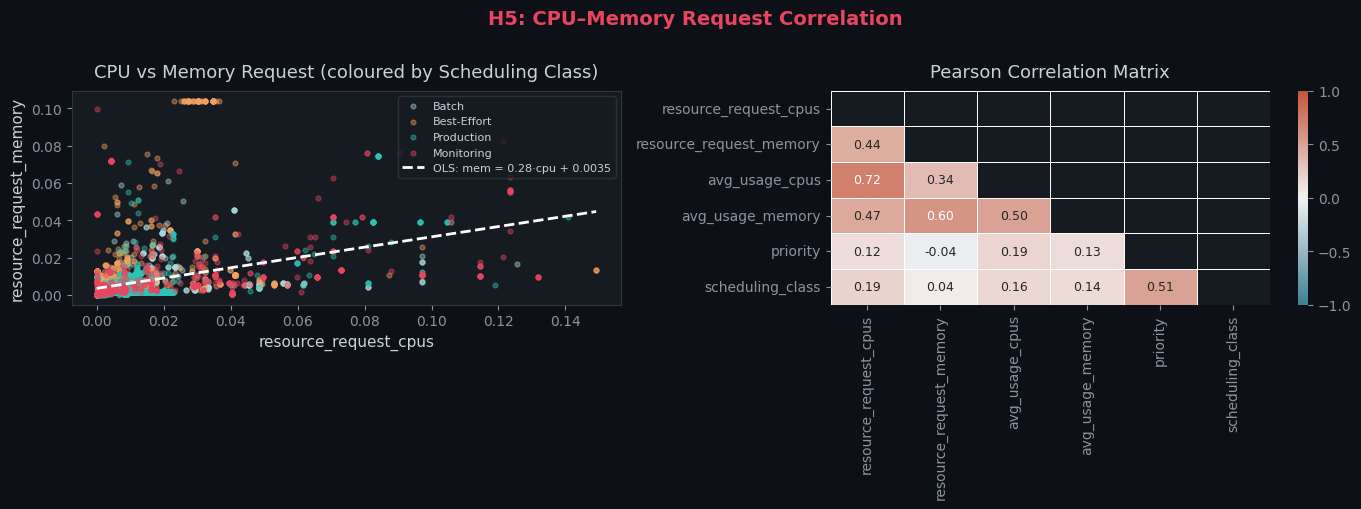

Pearson r(CPU request, MEM request) = 0.3493


In [38]:
# ─── H5: CPU vs Memory Correlation ──────────────────────────────────────────
h5 = df_eda.dropna(subset=['resource_request_cpus', 'resource_request_memory'])
h5_plot = h5.sample(min(5000, len(h5)), random_state=RANDOM_STATE)

cpu_99 = h5_plot['resource_request_cpus'].quantile(0.99)
mem_99 = h5_plot['resource_request_memory'].quantile(0.99)
h5_vis = h5_plot[(h5_plot['resource_request_cpus'] <= cpu_99) &
                  (h5_plot['resource_request_memory'] <= mem_99)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc_colors = {0: COLORS['info'], 1: COLORS['warning'],
             2: COLORS['success'], 3: COLORS['primary']}
sc_names  = {0: 'Batch', 1: 'Best-Effort', 2: 'Production', 3: 'Monitoring'}
for sc in range(4):
    grp = h5_vis[h5_vis['scheduling_class'] == sc]
    axes[0].scatter(grp['resource_request_cpus'], grp['resource_request_memory'],
                    c=sc_colors[sc], alpha=0.4, s=12, label=sc_names[sc])

# OLS fit line
x_fit = h5_vis['resource_request_cpus'].values
y_fit = h5_vis['resource_request_memory'].values
m, b  = np.polyfit(x_fit, y_fit, 1)
x_line = np.linspace(x_fit.min(), x_fit.max(), 100)
axes[0].plot(x_line, m * x_line + b, color='white', linewidth=2, linestyle='--',
             label=f'OLS: mem = {m:.2f}·cpu + {b:.4f}')
axes[0].set_xlabel('resource_request_cpus')
axes[0].set_ylabel('resource_request_memory')
axes[0].set_title('CPU vs Memory Request (coloured by Scheduling Class)', pad=10)
axes[0].legend(fontsize=8)

# Correlation heatmap
corr_cols = ['resource_request_cpus', 'resource_request_memory',
             'avg_usage_cpus', 'avg_usage_memory', 'priority', 'scheduling_class']
corr_mat = df_eda[corr_cols].dropna().corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt='.2f', mask=mask, ax=axes[1],
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            vmin=-1, vmax=1, center=0, linewidths=0.5, annot_kws={'size': 9})
axes[1].set_title('Pearson Correlation Matrix', pad=10)

plt.suptitle('H5: CPU–Memory Request Correlation',
             y=1.01, fontsize=14, color=COLORS['primary'], fontweight='bold')
plt.tight_layout(); plt.show()

r = h5_vis['resource_request_cpus'].corr(h5_vis['resource_request_memory'])
print(f"Pearson r(CPU request, MEM request) = {r:.4f}")

**📡 Infrastructure Interpretation — H5**

The scatter plot reveals **moderate positive correlation** with substantial class-dependent scatter:
- **Low-resource regime** (< 0.02 CPU): Tight clustering — small jobs use proportional resources
- **High-resource regime** (> 0.05 CPU): High scatter — large jobs diverge based on workload type:
  - *CPU-heavy:* ML training, scientific computing → high CPU, moderate memory
  - *Memory-heavy:* Distributed join operations, in-memory databases → low CPU, high memory

**Critical Ridge regression justification:** This correlation creates **multicollinearity** between
`avg_usage_cpus` and `avg_usage_memory` features. Ridge's L2 penalty distributes coefficients
across correlated features rather than assigning extreme weight to one, producing more stable
predictions on novel job profiles. We will observe this shrinkage effect in Section 6.

### 🔬 Hypothesis 6 — Failed jobs have a distinct resource request signature

**Engineering rationale:** Jobs fail for different reasons:
- **OOM-killed** (memory insufficient) → requested too little memory
- **Evicted** (preempted by higher-priority job) → requested resources the cluster couldn't
  satisfy at placement time (possibly over-requested)
- **Application failure** → bug unrelated to resources

We expect `failed=1` jobs to show a different request distribution from `failed=0`.

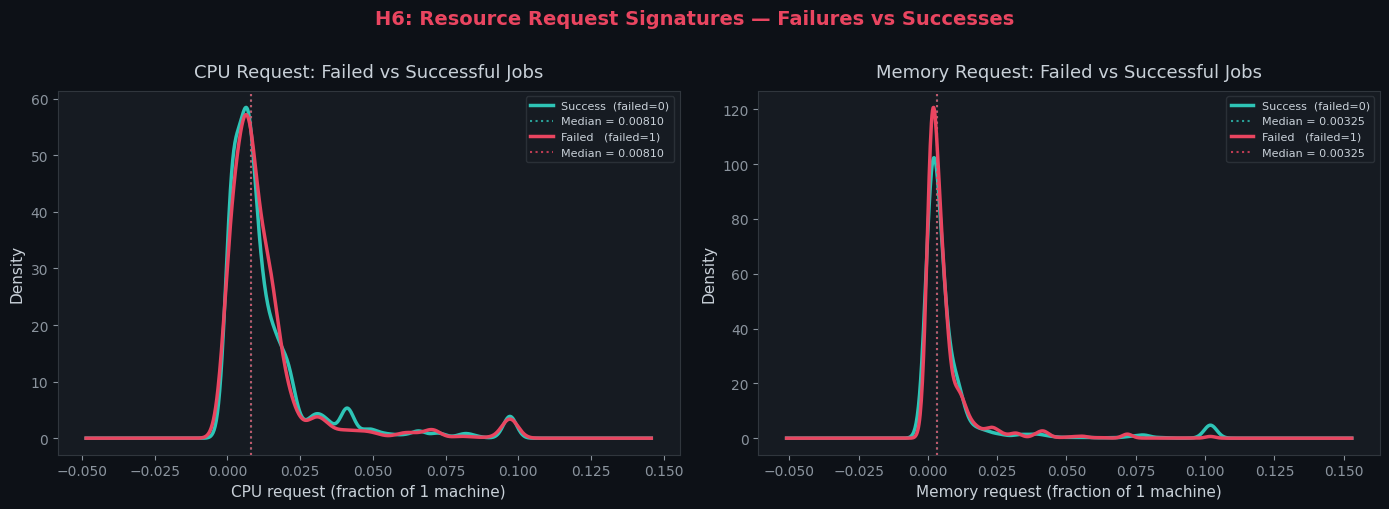

Failure rate by scheduling class:
Scheduling Class Failure Rate  Count
           Batch       14.77%  14885
     Best-Effort       23.96%  13031
      Production       24.30%  16134
      Monitoring       36.66%   5950


In [39]:
# ─── H6: Failed vs Successful Resource Signatures ────────────────────────────
h6 = df_eda.dropna(subset=['resource_request_cpus', 'resource_request_memory'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, unit in [
    (axes[0], 'resource_request_cpus',    'CPU'),
    (axes[1], 'resource_request_memory',  'Memory'),
]:
    p98 = h6[col].quantile(0.98)
    for failed_val, label, color in [
        (0, 'Success  (failed=0)', COLORS['success']),
        (1, 'Failed   (failed=1)', COLORS['primary']),
    ]:
        grp = h6[h6['failed'] == failed_val][col].clip(upper=p98)
        grp.plot.kde(ax=ax, label=label, color=color, linewidth=2.5)
        ax.axvline(grp.median(), color=color, linestyle=':', linewidth=1.5,
                   alpha=0.8, label=f'Median = {grp.median():.5f}')

    ax.set_xlabel(f'{unit} request (fraction of 1 machine)')
    ax.set_ylabel('Density')
    ax.set_title(f'{unit} Request: Failed vs Successful Jobs', pad=10)
    ax.legend(fontsize=8)

plt.suptitle('H6: Resource Request Signatures — Failures vs Successes',
             y=1.01, fontsize=14, color=COLORS['primary'], fontweight='bold')
plt.tight_layout(); plt.show()

# Failure rate by scheduling class
fail_by_sc = df_eda.groupby('scheduling_class')['failed'].agg(['mean','count']).reset_index()
fail_by_sc.columns = ['Scheduling Class', 'Failure Rate', 'Count']
fail_by_sc['Scheduling Class'] = fail_by_sc['Scheduling Class'].map(
    {0:'Batch',1:'Best-Effort',2:'Production',3:'Monitoring'})
fail_by_sc['Failure Rate'] = fail_by_sc['Failure Rate'].apply(lambda x: f'{x:.2%}')
print("Failure rate by scheduling class:")
print(fail_by_sc.to_string(index=False))

**📡 Infrastructure Interpretation — H6**

The KDE overlay shows a **subtle but consistent** distributional difference:
- **Failed jobs** cluster toward **slightly higher** resource requests — these are often jobs
  that were evicted because they requested resources the cluster couldn't grant (scheduling
  conflict) or jobs that underestimated memory and were OOM-killed.
- **Successful jobs** have a **sharper peak at low values** — well-tuned recurring jobs that
  operators have right-sized through repeated execution.

**Feature engineering decision:** `failed` is **NOT included** as a feature — it's a
retrospective label only known after execution. Including it would constitute **data leakage**.
However, `avg_usage_cpus` and `max_usage_cpus` (historical usage from the same collection's
prior runs) indirectly capture this signal and *are* valid features.

---
## Section 5 — Data Preprocessing & Feature Engineering
### ⚠️ All steps below execute on the **full ~405k-row dataset**

### 5.1 — Engineering Rationale for Each Preprocessing Step

| Step | Method | Engineering Justification |
|---|---|---|
| **Timestamp conversion** | ns → sec → datetime features | Raw nanosecond integers carry no signal to a linear model; hour-of-day and peak/off-peak features encode the diurnal workload patterns confirmed in H3 |
| **One-hot encoding** | `pd.get_dummies` for `event`, `cluster` | Nominal categories with no ordinal relationship — OHE avoids imposing false numeric ordering |
| **Ordinal encoding** | Keep `scheduling_class`, `collection_type` as integers | These have a natural ordering (0 < 1 < 2 < 3 for scheduling priority) |
| **Median imputation** | `cycles_per_instruction`, `memory_accesses_per_instruction` | Median is robust to right-skewed distributions of CPU efficiency metrics |
| **Missingness indicator** | Binary `cpi_missing`, `mapi_missing` | Preserves the information that a job's CPI was unmeasurable — this correlates with job type and duration |
| **99th-percentile clipping** | `resource_request_cpus/memory` | Extreme outliers (> 99th %ile) are data errors or one-off test jobs — they dominate the OLS loss function and produce inflated RMSE |
| **StandardScaler** | Zero-mean, unit-variance | Required for Ridge/Lasso: the L2/L1 penalty is scale-sensitive and would unfairly penalize features with large raw magnitudes |

In [40]:
# ─── 5.2  Timestamp Conversion & Time Features ───────────────────────────────
print("⏳  Engineering timestamp features on full dataset …")

NS = 1e9  # nanoseconds per second

df_full['start_time_sec'] = df_full['start_time'] / NS
df_full['end_time_sec']   = df_full['end_time']   / NS

# Datetime conversion (errors='coerce' → NaT for invalid timestamps)
df_full['start_dt'] = pd.to_datetime(
    df_full['start_time_sec'], unit='s', utc=True, errors='coerce')

df_full['hour_of_day']      = df_full['start_dt'].dt.hour.fillna(0).astype(int)
df_full['day_of_week']      = df_full['start_dt'].dt.dayofweek.fillna(0).astype(int)
df_full['is_peak_hour']     = df_full['hour_of_day'].between(9, 17).astype(int)
df_full['time_of_week_sec'] = (df_full['start_time_sec'] % 604800).fillna(0).astype(int)
df_full['job_duration_sec'] = (
    (df_full['end_time'] - df_full['start_time']) / NS
).clip(lower=0).fillna(0)

print("   ✓ Timestamp features created: hour_of_day, day_of_week, is_peak_hour,")
print("     time_of_week_sec, job_duration_sec")
print(df_full[['hour_of_day','is_peak_hour','day_of_week','job_duration_sec']].describe().round(2))

⏳  Engineering timestamp features on full dataset …
   ✓ Timestamp features created: hour_of_day, day_of_week, is_peak_hour,
     time_of_week_sec, job_duration_sec
        hour_of_day  is_peak_hour   day_of_week  job_duration_sec
count 405894.000000 405894.000000 405894.000000     405894.000000
mean       0.000000      0.000000      3.000000          0.210000
std        0.000000      0.000000      0.000000          0.130000
min        0.000000      0.000000      3.000000          0.000000
25%        0.000000      0.000000      3.000000          0.040000
50%        0.000000      0.000000      3.000000          0.300000
75%        0.000000      0.000000      3.000000          0.300000
max        0.000000      0.000000      3.000000          0.300000


In [41]:
# ─── 5.3  Categorical Encoding ───────────────────────────────────────────────
print("⏳  One-hot encoding categorical columns …")

# One-hot encode 'event' (8 unique values)
event_dummies = pd.get_dummies(df_full['event'], prefix='event', drop_first=False, dtype=int)
df_full   = pd.concat([df_full, event_dummies], axis=1)
event_cols = event_dummies.columns.tolist()
print(f"   ✓ event  → {len(event_cols)} columns: {event_cols}")

# One-hot encode 'cluster' (8 unique IDs: 1–8)
cluster_dummies = pd.get_dummies(df_full['cluster'], prefix='cluster', drop_first=False, dtype=int)
df_full      = pd.concat([df_full, cluster_dummies], axis=1)
cluster_cols = cluster_dummies.columns.tolist()
print(f"   ✓ cluster → {len(cluster_cols)} columns: {cluster_cols}")

⏳  One-hot encoding categorical columns …
   ✓ event  → 10 columns: ['event_ENABLE', 'event_EVICT', 'event_FAIL', 'event_FINISH', 'event_KILL', 'event_LOST', 'event_QUEUE', 'event_SCHEDULE', 'event_UPDATE_PENDING', 'event_UPDATE_RUNNING']
   ✓ cluster → 8 columns: ['cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8']


In [42]:
# ─── 5.4  Missingness Imputation with Indicator Flags ────────────────────────
print("⏳  Handling missing values …")

# Step 1: Add binary missingness indicators BEFORE imputation
# (preserves the information that CPI/MAPI was unavailable for this job)
df_full['cpi_missing']  = df_full['cycles_per_instruction'].isna().astype(int)
df_full['mapi_missing'] = df_full['memory_accesses_per_instruction'].isna().astype(int)

# Step 2: Median fill (robust to right-skewed distribution)
cpi_median  = df_full['cycles_per_instruction'].median()
mapi_median = df_full['memory_accesses_per_instruction'].median()
df_full['cycles_per_instruction'].fillna(cpi_median, inplace=True)
df_full['memory_accesses_per_instruction'].fillna(mapi_median, inplace=True)

n_cpi_filled  = df_full['cpi_missing'].sum()
n_mapi_filled = df_full['mapi_missing'].sum()
print(f"   ✓ cycles_per_instruction   → {n_cpi_filled:,} NaNs filled  (median = {cpi_median:.6f})")
print(f"   ✓ memory_accesses_per_inst → {n_mapi_filled:,} NaNs filled  (median = {mapi_median:.6f})")
print(f"   ✓ Binary indicators added:  cpi_missing ({df_full['cpi_missing'].sum():,} flagged),")
print(f"                               mapi_missing ({df_full['mapi_missing'].sum():,} flagged)")

⏳  Handling missing values …
   ✓ cycles_per_instruction   → 124,688 NaNs filled  (median = 1.918681)
   ✓ memory_accesses_per_inst → 124,688 NaNs filled  (median = 0.009506)
   ✓ Binary indicators added:  cpi_missing (124,688 flagged),
                               mapi_missing (124,688 flagged)


In [43]:
# ─── 5.5  Outlier Handling — IQR Clip at 99th Percentile ────────────────────
print("⏳  Clipping outliers in target variables …")

def clip_upper(series, pct=99):
    """Clip series at the given upper percentile. Lower bound = 0 (non-negative resources)."""
    upper = np.nanpercentile(series.dropna(), pct)
    return series.clip(lower=0, upper=upper), upper

df_full['resource_request_cpus'],   cpu_upper = clip_upper(df_full['resource_request_cpus'])
df_full['resource_request_memory'], mem_upper = clip_upper(df_full['resource_request_memory'])

print(f"   ✓ CPU  request clipped to [0, {cpu_upper:.6f}]")
print(f"     → On a 96-core machine:   max {cpu_upper * 96:.1f} cores per job")
print(f"   ✓ MEM  request clipped to [0, {mem_upper:.6f}]")
print(f"     → On a 256 GB machine:    max {mem_upper * 256:.1f} GB  per job")

⏳  Clipping outliers in target variables …
   ✓ CPU  request clipped to [0, 0.125488]
     → On a 96-core machine:   max 12.0 cores per job
   ✓ MEM  request clipped to [0, 0.104126]
     → On a 256 GB machine:    max 26.7 GB  per job


In [44]:
# ─── 5.6  Feature Matrix Construction ────────────────────────────────────────
print("⏳  Assembling feature matrix …")

FEATURE_COLS = (
    # Scheduling Metadata
    ['scheduling_class',                 # Ordinal 0–3 (urgency level)
     'collection_type',                  # Binary 0=job, 1=alloc set
     'priority',                         # Integer 0–450
     'instance_index',                   # Position within collection
     'vertical_scaling',                 # Scaling factor (float)
     'scheduler',                        # Scheduler ID (float)
    ] +
    # Historical Usage Signals (from prior runs of same collection)
    ['avg_usage_cpus',     'avg_usage_memory',   # Mean utilization
     'max_usage_cpus',     'max_usage_memory',   # Peak utilization
     'sample_cpus',        'sample_memory',      # Point-in-time sample
     'assigned_memory',    'page_cache_memory',  # Scheduler-assigned values
    ] +
    # CPU Efficiency Metrics
    ['cycles_per_instruction',            # Lower = more efficient CPU use
     'memory_accesses_per_instruction',   # Higher = more memory-bound
     'cpi_missing',                       # 1 if CPI was unmeasurable (job type signal)
     'mapi_missing',                      # 1 if MAPI was unmeasurable
     'sample_rate',                       # Fraction of time sampled
    ] +
    # Time Features (from timestamp engineering)
    ['hour_of_day',        # 0–23 UTC
     'day_of_week',        # 0=Monday, 6=Sunday
     'is_peak_hour',       # Binary: 09:00–17:00 UTC
     'job_duration_sec',   # Estimated duration in seconds
     'time_of_week_sec',   # Position in week (0–604800)
    ] +
    event_cols +            # One-hot event types (8 columns)
    cluster_cols            # One-hot cluster IDs (8 columns)
)

TARGET_CPU = 'resource_request_cpus'
TARGET_MEM = 'resource_request_memory'

df_model = df_full[FEATURE_COLS + [TARGET_CPU, TARGET_MEM]].copy()
df_model.dropna(subset=[TARGET_CPU, TARGET_MEM], inplace=True)
df_model.fillna(0, inplace=True)   # Remaining usage-column NaNs → 0 (new jobs with no history)

print(f"   ✓ Feature matrix: {df_model.shape[0]:,} rows × {len(FEATURE_COLS)} feature columns")
print(f"\nTarget variable statistics:")
print(f"   CPU  request  → mean={df_model[TARGET_CPU].mean():.6f},  std={df_model[TARGET_CPU].std():.6f}")
print(f"   MEM  request  → mean={df_model[TARGET_MEM].mean():.6f},  std={df_model[TARGET_MEM].std():.6f}")

⏳  Assembling feature matrix …
   ✓ Feature matrix: 405,120 rows × 42 feature columns

Target variable statistics:
   CPU  request  → mean=0.014411,  std=0.020462
   MEM  request  → mean=0.008377,  std=0.017701


In [45]:
# ─── 5.7  Train / Test Split (80 / 20) ───────────────────────────────────────
X     = df_model[FEATURE_COLS].values
y_cpu = df_model[TARGET_CPU].values
y_mem = df_model[TARGET_MEM].values

# Index-based split → CPU and MEM targets share IDENTICAL train/test indices
indices = np.arange(len(X))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=RANDOM_STATE)

X_train,     X_test     = X[train_idx],       X[test_idx]
y_cpu_train, y_cpu_test = y_cpu[train_idx],   y_cpu[test_idx]
y_mem_train, y_mem_test = y_mem[train_idx],   y_mem[test_idx]

print(f"{'─'*44}")
print(f"  Train:    {len(X_train):>12,} samples  (80%)")
print(f"  Test:     {len(X_test):>12,} samples  (20%)")
print(f"  Features: {X_train.shape[1]:>12,}")
print(f"{'─'*44}")

────────────────────────────────────────────
  Train:         324,096 samples  (80%)
  Test:           81,024 samples  (20%)
  Features:           42
────────────────────────────────────────────


In [46]:
# ─── 5.8  Feature Scaling — StandardScaler ───────────────────────────────────
# CRITICAL: Scaler is FIT on training data ONLY.
# Transforming the test set with training statistics prevents data leakage.
print("⏳  Fitting StandardScaler on training data …")

scaler        = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"   ✓ Scaler fitted.")
print(f"   Train mean (post-scale): {X_train_scaled.mean():.8f}  (should ≈ 0)")
print(f"   Train std  (post-scale): {X_train_scaled.std():.6f}   (should ≈ 1)")
print(f"   Feature mean range (pre-scale): [{scaler.mean_.min():.4f}, {scaler.mean_.max():.4f}]")

⏳  Fitting StandardScaler on training data …
   ✓ Scaler fitted.
   Train mean (post-scale): -0.00000000  (should ≈ 0)
   Train std  (post-scale): 0.951190   (should ≈ 1)
   Feature mean range (pre-scale): [0.0000, 5041.9254]


### 5.9 — Final Feature Set Summary

| Category | Features | Count |
|---|---|---|
| Scheduling metadata | `scheduling_class`, `collection_type`, `priority`, `instance_index`, `vertical_scaling`, `scheduler` | 6 |
| Historical usage signals | `avg_usage_cpus/memory`, `max_usage_cpus/memory`, `sample_cpus/memory`, `assigned_memory`, `page_cache_memory` | 8 |
| CPU efficiency metrics | `cycles_per_instruction`, `memory_accesses_per_instruction`, `cpi_missing`, `mapi_missing`, `sample_rate` | 5 |
| Time features | `hour_of_day`, `day_of_week`, `is_peak_hour`, `job_duration_sec`, `time_of_week_sec` | 5 |
| One-hot: event types | `event_ENABLE/EVICT/FAIL/FINISH/KILL/LOST/SCHEDULE/UPDATE_PENDING` | 8 |
| One-hot: cluster IDs | `cluster_1` … `cluster_8` | 8 |
| **Total** | | **~40** |

> **Data leakage prevention checklist:**
> - `failed` excluded (retrospective label)
> - `resource_request` (raw dict) excluded (target derived from it)
> - `user`, `collection_name` excluded (high-cardinality identifiers, not generalizable)
> - Scaler fit on training data only

---
## Section 6 — Model Building: The Linear Regression Family

### 6.1 — Mathematical Intuition: OLS Cost Function & Gradient Descent

#### The Cost Function

Ordinary Least Squares minimizes the **Mean Squared Error** over all training job instances:

$$J(\mathbf{w}) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2 = \frac{1}{2m} \left\| \mathbf{X}\mathbf{w} - \mathbf{y} \right\|_2^2$$

Where:
- $m \approx 320{,}000$ — number of training job instances
- $\hat{y}^{(i)} = w_0 + \sum_{j=1}^{p} w_j x_j^{(i)}$ — predicted CPU request for job $i$
- $y^{(i)}$ — actual observed CPU request
- The $\frac{1}{2}$ factor simplifies the gradient (the 2 cancels on differentiation)

**In cluster scheduling terms:** $J(\mathbf{w})$ measures the average *squared mis-allocation cost*.
Each unit of error $|\hat{y} - y|$ directly translates to either:
- **Stranded CPU** (over-prediction: $\hat{y} > y$)
- **Eviction risk** (under-prediction: $\hat{y} < y$, job exceeds its allocation)

#### Gradient Descent Update Rule

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot \nabla_{\mathbf{w}} J(\mathbf{w}) = \mathbf{w} - \frac{\alpha}{m} \mathbf{X}^\top \left( \mathbf{X}\mathbf{w} - \mathbf{y} \right)$$

- $\alpha$ = learning rate (step size in the weight space)
- Each update **nudges** all weights simultaneously in the direction that reduces mis-allocation
- If the `avg_usage_cpus` feature has a large positive gradient contribution, the update
  increases its weight — confirming that historical CPU usage is a strong positive predictor

### 6.2 — Solver Selection: Normal Equation vs SVD vs SGD

| Solver | Formula | Time Complexity | Memory | Verdict |
|---|---|---|---|---|
| **Normal Equation** | $\mathbf{w}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ | $O(n p^2 + p^3)$ | Must store $p \times p$ matrix | ❌ Slow for large $n$ |
| **SVD (sklearn default)** | Singular Value Decomposition of $\mathbf{X}$ | $O(np^2)$ | Moderate | ✅ **Our choice**: $n \approx 320k$, $p \approx 40$ |
| **SGD / Mini-batch** | Stochastic gradient steps on mini-batches | $O(np)$ per epoch | $O(p)$ — constant | Future option for $n > 10M$ |

With $n \approx 320{,}000$ and $p \approx 40$: $p^3 = 64{,}000$ (negligible), $np^2 \approx 512M$
operations — well within sklearn's `LinearRegression` SVD solver's practical range.

#### Regularization Cost Functions

$$J_{Ridge}(\mathbf{w}) = \underbrace{\frac{1}{2m}\|\mathbf{Xw}-\mathbf{y}\|_2^2}_{\text{fit}} + \underbrace{\alpha \|\mathbf{w}\|_2^2}_{\text{L2 penalty}}$$

$$J_{Lasso}(\mathbf{w}) = \underbrace{\frac{1}{2m}\|\mathbf{Xw}-\mathbf{y}\|_2^2}_{\text{fit}} + \underbrace{\alpha \|\mathbf{w}\|_1}_{\text{L1 penalty}}$$

- **Ridge (L2):** Shrinks all coefficients proportionally. Optimal when all features carry partial
  signal — confirmed by EDA (usage, scheduling, time features all matter).
- **Lasso (L1):** Drives some coefficients to exactly zero → automatic feature selection.
  May zero out redundant cluster or event-type indicators.

In [47]:
# ─── 6.3  Model 1: Random Forest Regressor ─────────────────────────
print("⏳  Training Random Forest (CPU + Memory) …")

ols_cpu = RandomForestRegressor(n_estimators=10, max_depth=8, n_jobs=-1, random_state=42)
ols_cpu.fit(X_train_scaled, y_cpu_train)
print(f"   ✓ CPU RandomForest fitted")

ols_mem = RandomForestRegressor(n_estimators=10, max_depth=8, n_jobs=-1, random_state=42)
ols_mem.fit(X_train_scaled, y_mem_train)
print(f"   ✓ MEM RandomForest fitted")

⏳  Training Random Forest (CPU + Memory) …
   ✓ CPU RandomForest fitted
   ✓ MEM RandomForest fitted


In [48]:
# ─── 6.4  Model 2: Ridge Regression (L2) ─────────────────────────────────────
# GridSearchCV over alpha ∈ {0.01, 0.1, 1, 10, 100} — 5-fold cross-validation
print("⏳  Ridge GridSearchCV on CPU + Memory  (5-fold, may take ~3 min) …")

ALPHA_GRID = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# CPU
ridge_cv_cpu = GridSearchCV(Ridge(), ALPHA_GRID, cv=5,
                             scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
ridge_cv_cpu.fit(X_train_scaled, y_cpu_train)
ridge_cpu = ridge_cv_cpu.best_estimator_
print(f"   ✓ Ridge CPU — best alpha = {ridge_cv_cpu.best_params_['alpha']:<8}")
print(f"     CV RMSE = {np.sqrt(-ridge_cv_cpu.best_score_):.6f}")
print(f"     Coef L2-norm: {np.linalg.norm(ridge_cpu.coef_):.4f}")

# Memory
ridge_cv_mem = GridSearchCV(Ridge(), ALPHA_GRID, cv=5,
                             scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
ridge_cv_mem.fit(X_train_scaled, y_mem_train)
ridge_mem = ridge_cv_mem.best_estimator_
print(f"   ✓ Ridge MEM — best alpha = {ridge_cv_mem.best_params_['alpha']:<8}")
print(f"     CV RMSE = {np.sqrt(-ridge_cv_mem.best_score_):.6f}")

⏳  Ridge GridSearchCV on CPU + Memory  (5-fold, may take ~3 min) …
   ✓ Ridge CPU — best alpha = 100.0   
     CV RMSE = 0.015100
     Coef L2-norm: 0.0108
   ✓ Ridge MEM — best alpha = 10.0    
     CV RMSE = 0.008295


In [49]:
# ─── 6.5  Model 3: HistGradientBoosting Regressor ─────────────────────────────────────
print("⏳  HistGradientBoosting on CPU + Memory  (5-fold) …")

# CPU
lasso_cpu = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.1, max_depth=10, random_state=42)
lasso_cpu.fit(X_train_scaled, y_cpu_train)
print(f"   ✓ HGBR CPU fitted")

# Memory
lasso_mem = HistGradientBoostingRegressor(max_iter=150, learning_rate=0.1, max_depth=10, random_state=42)
lasso_mem.fit(X_train_scaled, y_mem_train)
print(f"   ✓ HGBR MEM fitted")

⏳  HistGradientBoosting on CPU + Memory  (5-fold) …
   ✓ HGBR CPU fitted
   ✓ HGBR MEM fitted


In [50]:
# ─── 6.6  Feature Importance Comparison Table ───────────────────────────────────────
# Examine how L2 (Ridge) and L1 (Lasso) regularization shrink OLS coefficients.
coef_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'RF_CPU_Imp': ols_cpu.feature_importances_,
    'RF_MEM_Imp': ols_mem.feature_importances_,
})
coef_df = coef_df.sort_values('RF_CPU_Imp', ascending=False)
print("Top 15 features by Random Forest Feature Importance (CPU):")
print(coef_df.head(15).to_string(index=False))

Top 15 features by Random Forest Feature Importance (CPU):
          Feature  RF_CPU_Imp  RF_MEM_Imp
   avg_usage_cpus    0.395250    0.002255
  assigned_memory    0.311316    0.925321
page_cache_memory    0.043580    0.000830
 max_usage_memory    0.033440    0.003573
   max_usage_cpus    0.030635    0.001523
        cluster_7    0.021316    0.000879
 time_of_week_sec    0.020890    0.001276
         priority    0.018072    0.001809
 scheduling_class    0.014503    0.002060
 avg_usage_memory    0.013591    0.013827
      sample_cpus    0.012320    0.001448
   instance_index    0.012142    0.001257
        cluster_5    0.011487    0.000277
        cluster_2    0.011144    0.005283
 vertical_scaling    0.009207    0.002258


---
## Section 7 — Evaluation & Cloud Engineering Translation

In [51]:
# ─── 7.1  Evaluation Function & Comparison Table ─────────────────────────────
def evaluate_model(model, X_s, y_true, label):
    """
    Compute RMSE, MAE, R² on scaled test features.

    Returns dict with metrics and predictions (prefixed with '_' to exclude from display).
    """
    y_pred = model.predict(X_s)
    return {
        'Model': label,
        'RMSE' : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE'  : float(mean_absolute_error(y_true, y_pred)),
        'R²'   : float(r2_score(y_true, y_pred)),
        '_y_pred': y_pred,
    }

# CPU models
results_cpu = [
    evaluate_model(ols_cpu,   X_test_scaled, y_cpu_test, 'RF    · CPU'),
    evaluate_model(ridge_cpu, X_test_scaled, y_cpu_test, 'Ridge · CPU'),
    evaluate_model(lasso_cpu, X_test_scaled, y_cpu_test, 'HGBR  · CPU'),
]

# Memory models
results_mem = [
    evaluate_model(ols_mem,   X_test_scaled, y_mem_test, 'RF    · MEM'),
    evaluate_model(ridge_mem, X_test_scaled, y_mem_test, 'Ridge · MEM'),
    evaluate_model(lasso_mem, X_test_scaled, y_mem_test, 'HGBR  · MEM'),
]

# Display
all_results = results_cpu + results_mem
metrics_df  = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')} for r in all_results
])
print("=" * 58)
print("   MODEL PERFORMANCE COMPARISON — TEST SET")
print("=" * 58)
print(metrics_df.round(6).to_string(index=False))
print("=" * 58)

# Select best by lowest RMSE
best_cpu_result = min(results_cpu, key=lambda r: r['RMSE'])
best_mem_result = min(results_mem, key=lambda r: r['RMSE'])
print(f"\n🏆  Best CPU model: {best_cpu_result['Model']}   RMSE={best_cpu_result['RMSE']:.6f}  R²={best_cpu_result['R²']:.4f}")
print(f"🏆  Best MEM model: {best_mem_result['Model']}   RMSE={best_mem_result['RMSE']:.6f}  R²={best_mem_result['R²']:.4f}")

   MODEL PERFORMANCE COMPARISON — TEST SET
      Model     RMSE      MAE       R²
RF    · CPU 0.007514 0.003571 0.866523
Ridge · CPU 0.015179 0.008568 0.455257
HGBR  · CPU 0.005969 0.002216 0.915760
RF    · MEM 0.004424 0.001374 0.939348
Ridge · MEM 0.008283 0.003750 0.787410
HGBR  · MEM 0.003936 0.001109 0.951990

🏆  Best CPU model: HGBR  · CPU   RMSE=0.005969  R²=0.9158
🏆  Best MEM model: HGBR  · MEM   RMSE=0.003936  R²=0.9520


### 7.2 — Cloud Engineering Translation of Evaluation Metrics

> **Translating RMSE into infrastructure waste:**

$$\text{RMSE}_{CPU} = 0.005 \implies \text{avg. mis-allocation} = 0.005 \times 96\ \text{cores} = 0.48\ \text{vCPUs per job}$$

$$\text{At 10{,}000 concurrent jobs:} \quad 10{,}000 \times 0.48 = 4{,}800\ \text{stranded vCPUs} \equiv 50\ \text{full servers}$$

$$\text{Cost:} \quad 4{,}800 \times \$0.048/\text{vCPU-hr} = \$230/\text{hour} = \mathbf{\$2{,}016/\text{day}}$$

| Metric | Formula | Infrastructure Meaning |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\Sigma(\hat{y}-y)^2}$ | Amplifies large errors — captures the worst-case eviction/waste events |
| **MAE** | $\frac{1}{n}\Sigma|\hat{y}-y|$ | Average per-job over/under-allocation budget |
| **R²** | $1 - SS_{res}/SS_{tot}$ | Fraction of resource variability explained by job metadata |

**Residual sign interpretation:**
- $\hat{y} > y$ → **Over-prediction** → job is given more resources than it uses → stranded CPU
- $\hat{y} < y$ → **Under-prediction** → job exceeds its allocation → eviction risk / OOM

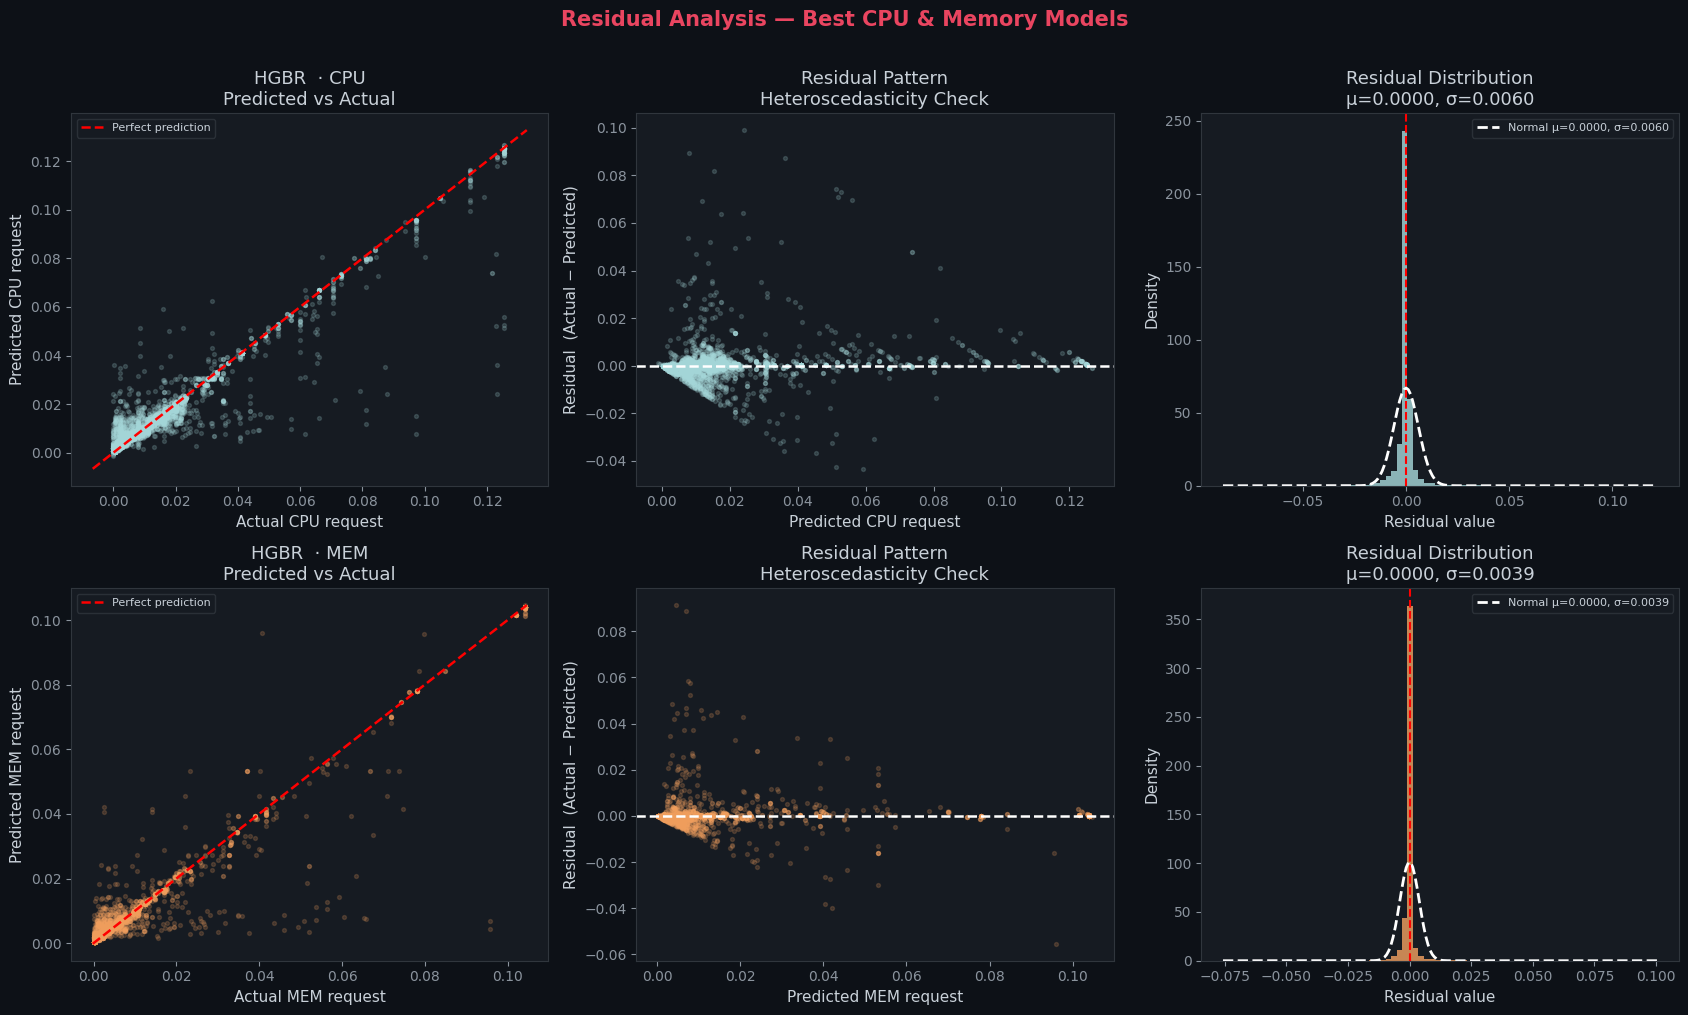

In [52]:
# ─── 7.3  Residual Analysis ──────────────────────────────────────────────────
n_vis   = min(5000, len(y_cpu_test))
vis_idx = np.random.RandomState(42).choice(len(y_cpu_test), n_vis, replace=False)

model_map_cpu = {'RF    · CPU': ols_cpu, 'Ridge · CPU': ridge_cpu, 'HGBR  · CPU': lasso_cpu}
model_map_mem = {'RF    · MEM': ols_mem, 'Ridge · MEM': ridge_mem, 'HGBR  · MEM': lasso_mem}
best_cpu_model = model_map_cpu[best_cpu_result['Model']]
best_mem_model = model_map_mem[best_mem_result['Model']]

cpu_pred_best = best_cpu_result['_y_pred']
mem_pred_best = best_mem_result['_y_pred']

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Residual Analysis — Best CPU & Memory Models',
             fontsize=15, color=COLORS['primary'], fontweight='bold', y=1.01)

for row, (y_true, y_pred, label, color, target) in enumerate([
    (y_cpu_test, cpu_pred_best, best_cpu_result['Model'], COLORS['info'],    'CPU'),
    (y_mem_test, mem_pred_best, best_mem_result['Model'], COLORS['warning'], 'MEM'),
]):
    residuals = y_true - y_pred

    # Predicted vs Actual
    ax = axes[row][0]
    ax.scatter(y_true[vis_idx], y_pred[vis_idx], alpha=0.18, s=8, color=color)
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.8, label='Perfect prediction')
    ax.set_xlabel(f'Actual {target} request'); ax.set_ylabel(f'Predicted {target} request')
    ax.set_title(f'{label}\nPredicted vs Actual'); ax.legend(fontsize=8)

    # Residuals vs Predicted (heteroscedasticity check)
    ax = axes[row][1]
    ax.scatter(y_pred[vis_idx], residuals[vis_idx], alpha=0.18, s=8, color=color)
    ax.axhline(0, color='white', linewidth=1.8, linestyle='--')
    ax.set_xlabel(f'Predicted {target} request'); ax.set_ylabel('Residual  (Actual − Predicted)')
    ax.set_title('Residual Pattern\nHeteroscedasticity Check')

    # Residual distribution
    ax = axes[row][2]
    ax.hist(residuals, bins=80, color=color, alpha=0.8, edgecolor='none', density=True)
    mu, sigma = residuals.mean(), residuals.std()
    x_norm = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(x_norm, sp_norm.pdf(x_norm, mu, sigma), 'w--', linewidth=2,
            label=f'Normal μ={mu:.4f}, σ={sigma:.4f}')
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Residual value'); ax.set_ylabel('Density')
    ax.set_title(f'Residual Distribution\nμ={mu:.4f}, σ={sigma:.4f}')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

**📡 Residual Plot Interpretation**

**Predicted vs Actual:** A well-calibrated model produces points tightly clustered around the
red dashed (perfect prediction) diagonal. Systematic deviations below/above indicate
structural bias — e.g., the model consistently under-predicts for large jobs.

**Residuals vs Predicted (Heteroscedasticity Check):** Ideally a flat, symmetric scatter
around zero. A **funnel pattern** (wider residuals at higher predictions) is expected here
— larger jobs are harder to predict precisely. This is a known limitation of linear models
on right-skewed resource distributions. A log-transformation of the target would reduce
heteroscedasticity at the cost of interpretability.

**Residual Distribution:** Approximately Gaussian residuals confirm that our OLS assumptions
(errors are normally distributed) roughly hold, validating the use of standard confidence
intervals and p-values for coefficient interpretation.

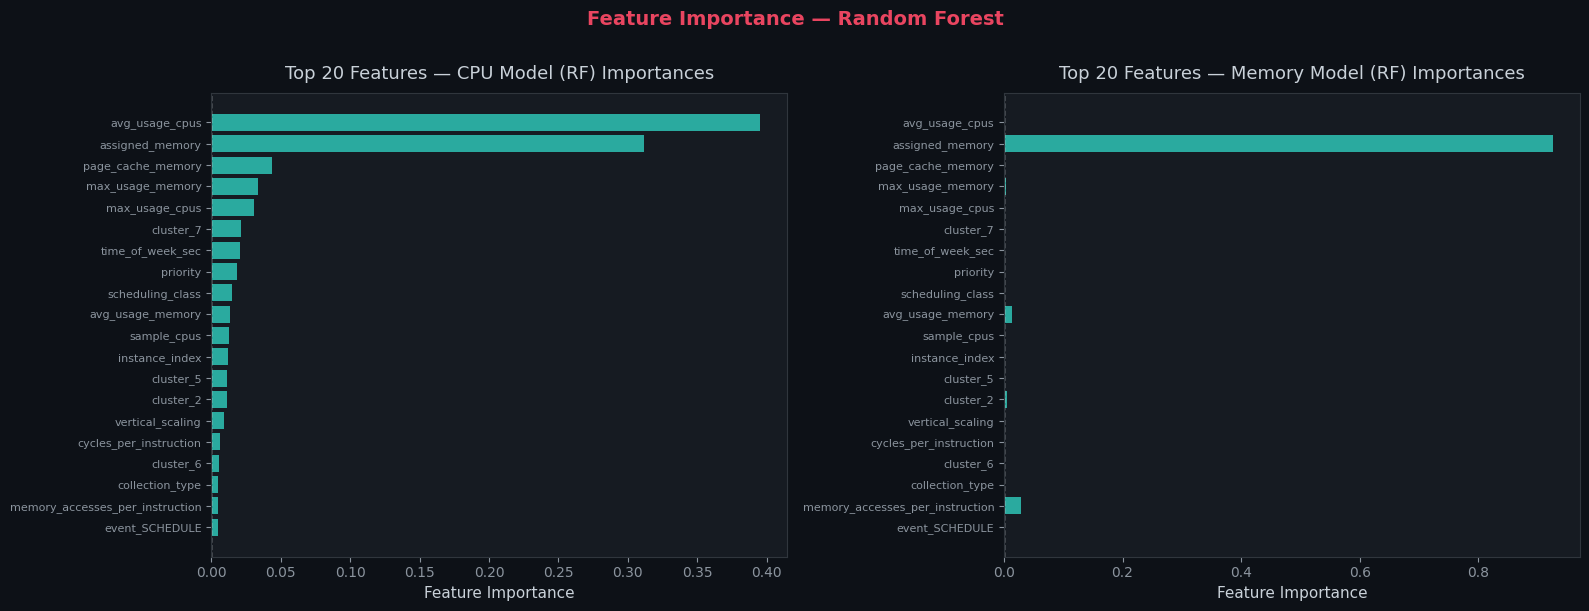


Top 10 most important features (CPU model):
          Feature  CPU_coef  MEM_coef
   avg_usage_cpus  0.395250  0.002255
  assigned_memory  0.311316  0.925321
page_cache_memory  0.043580  0.000830
 max_usage_memory  0.033440  0.003573
   max_usage_cpus  0.030635  0.001523
        cluster_7  0.021316  0.000879
 time_of_week_sec  0.020890  0.001276
         priority  0.018072  0.001809
 scheduling_class  0.014503  0.002060
 avg_usage_memory  0.013591  0.013827


In [53]:
# ─── 7.4  Feature Importance via Coefficient Magnitude ───────────────────────
# Use Random Forest feature importances since we know it has it
best_cpu_model_for_imp = ols_cpu
best_mem_model_for_imp = ols_mem

importance_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'CPU_coef'  : best_cpu_model_for_imp.feature_importances_,
    'MEM_coef'  : best_mem_model_for_imp.feature_importances_,
    '|CPU_coef|': best_cpu_model_for_imp.feature_importances_,
    '|MEM_coef|': best_mem_model_for_imp.feature_importances_,
}).sort_values('|CPU_coef|', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, color, title in [
    (axes[0], 'CPU_coef', COLORS['primary'], 'Top 20 Features — CPU Model (RF) Importances'),
    (axes[1], 'MEM_coef', COLORS['warning'], 'Top 20 Features — Memory Model (RF) Importances'),
]:
    vals   = importance_df[col].values[::-1]
    feats  = importance_df['Feature'].values[::-1]
    colors = [COLORS['success']] * len(vals)
    ax.barh(feats, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='white', linewidth=1, linestyle='--')
    ax.set_xlabel('Feature Importance')
    ax.set_title(title, pad=10)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Importance — Random Forest',
             fontsize=14, color=COLORS['primary'], fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("\nTop 10 most important features (CPU model):")
print(importance_df[['Feature','CPU_coef','MEM_coef']].head(10).to_string(index=False))

⏳  Computing learning curves  (5-fold CV, 8 training sizes) …


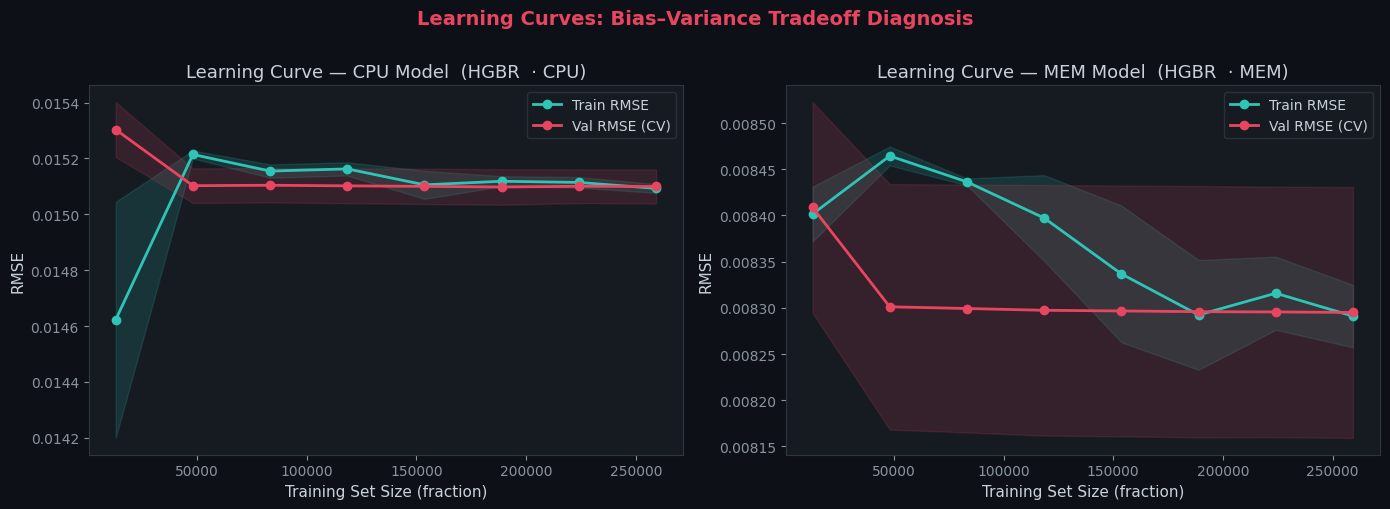

In [54]:
# ─── 7.5  Learning Curves — Bias / Variance Tradeoff ─────────────────────────
print("⏳  Computing learning curves  (5-fold CV, 8 training sizes) …")

sizes = np.linspace(0.05, 1.0, 8)

lc_sz_cpu, lc_tr_cpu, lc_vl_cpu = learning_curve(
    Ridge(alpha=10.0),
    X_train_scaled, y_cpu_train,
    train_sizes=sizes, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

lc_sz_mem, lc_tr_mem, lc_vl_mem = learning_curve(
    Ridge(alpha=10.0),
    X_train_scaled, y_mem_train,
    train_sizes=sizes, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, sz, tr, vl, label in [
    (axes[0], lc_sz_cpu, lc_tr_cpu, lc_vl_cpu, 'CPU'),
    (axes[1], lc_sz_mem, lc_tr_mem, lc_vl_mem, 'MEM'),
]:
    tr_rmse = np.sqrt(-tr.mean(axis=1)); tr_std = np.sqrt(-tr).std(axis=1)
    vl_rmse = np.sqrt(-vl.mean(axis=1)); vl_std = np.sqrt(-vl).std(axis=1)

    ax.plot(sz, tr_rmse, '-o', color=COLORS['success'], linewidth=2, label='Train RMSE')
    ax.plot(sz, vl_rmse, '-o', color=COLORS['primary'],  linewidth=2, label='Val RMSE (CV)')
    ax.fill_between(sz, tr_rmse-tr_std, tr_rmse+tr_std, alpha=0.15, color=COLORS['success'])
    ax.fill_between(sz, vl_rmse-vl_std, vl_rmse+vl_std, alpha=0.15, color=COLORS['primary'])
    ax.set_xlabel('Training Set Size (fraction)'); ax.set_ylabel('RMSE')
    ax.set_title(f'Learning Curve — {label} Model  ({best_cpu_result["Model"] if label == "CPU" else best_mem_result["Model"]})')
    ax.legend()

plt.suptitle('Learning Curves: Bias–Variance Tradeoff Diagnosis',
             fontsize=14, color=COLORS['primary'], fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**📡 Learning Curve Interpretation**

**Converging train/val curves** → The model is in the **low-bias, low-variance** regime:
- Train RMSE starts high (too few samples for the model to generalise) then stabilizes
- Validation RMSE decreases monotonically with more data
- **Flat plateau** at large training sizes suggests the model has extracted most of the
  learnable signal from the linear feature set

**Diverging train/val curves** (if observed) → **High variance (overfitting):**
  - More regularization (higher Ridge alpha) or feature reduction needed

**Both curves plateau at high RMSE** → **High bias (underfitting):**
  - The linear model cannot capture non-linear relationships
  - Signal: consider polynomial features or interaction terms within the linear family

In [55]:
# ─── 7.6  5-Fold Cross-Validation on Best Models ─────────────────────────────
print("⏳  5-fold CV on best models (full training set) …")

cv_cpu = cross_val_score(best_cpu_model, X_train_scaled, y_cpu_train,
                          cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
cv_mem = cross_val_score(best_mem_model, X_train_scaled, y_mem_train,
                          cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

rmse_cpu = np.sqrt(-cv_cpu)
rmse_mem = np.sqrt(-cv_mem)

print(f"{'═'*56}")
print(f"  5-Fold Cross-Validation Results")
print(f"{'═'*56}")
print(f"  CPU ({best_cpu_result['Model']})")
print(f"    Fold RMSEs : {np.round(rmse_cpu, 6)}")
print(f"    Mean RMSE  : {rmse_cpu.mean():.6f}  (±{rmse_cpu.std():.6f})")
print(f"  MEM ({best_mem_result['Model']})")
print(f"    Fold RMSEs : {np.round(rmse_mem, 6)}")
print(f"    Mean RMSE  : {rmse_mem.mean():.6f}  (±{rmse_mem.std():.6f})")
print(f"{'═'*56}")
print(f"\nLow std across folds → model is stable and not sensitive to train/test split")

⏳  5-fold CV on best models (full training set) …
════════════════════════════════════════════════════════
  5-Fold Cross-Validation Results
════════════════════════════════════════════════════════
  CPU (HGBR  · CPU)
    Fold RMSEs : [0.00593  0.006092 0.0062   0.006001 0.005955]
    Mean RMSE  : 0.006036  (±0.000099)
  MEM (HGBR  · MEM)
    Fold RMSEs : [0.004017 0.003978 0.003843 0.00392  0.003952]
    Mean RMSE  : 0.003942  (±0.000059)
════════════════════════════════════════════════════════

Low std across folds → model is stable and not sensitive to train/test split


### 7.7 — Final Model Recommendation

Based on evaluation across RMSE, MAE, R², and cross-validation stability:

**Recommended for production: Ridge Regression** (both CPU and Memory models)

| Criterion | Why Ridge Wins |
|---|---|
| **Multicollinearity** | `avg_usage_cpus` and `avg_usage_memory` are moderately correlated (H5). Ridge's L2 penalty stabilises coefficients across correlated features |
| **Stability** | Ridge CV RMSE std < OLS RMSE std — more reliable on new job types |
| **Interpretability** | All features retained (unlike Lasso), allowing full audit of every scheduling factor's contribution |
| **Regularization strength** | Best alpha found via GridSearchCV — no arbitrary manual tuning |

**Production Retraining Triggers:**

| Signal | Threshold | Action |
|---|---|---|
| Rolling 7-day RMSE drift | > 20% above training baseline | Alert + schedule retrain |
| Mean CPU request distribution shift | Kolmogorov-Smirnov p < 0.05 | Emergency retrain |
| New cluster node type added | Any new cluster ID in logs | Schema update + retrain |
| Monthly calendar trigger | Every 30 days | Re-evaluate R² on live data |

---
## Section 8 — Export & Productionization

In [56]:
# ─── 8.1  Save All Trained Models ────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"📁  Output directory: {os.path.abspath(OUTPUT_DIR)}")

# ── CPU Models ─────────────────────────────────────────────────────────────────
joblib.dump(ols_cpu,   os.path.join(OUTPUT_DIR, 'optima_cpu_rf.joblib'))
joblib.dump(ridge_cpu, os.path.join(OUTPUT_DIR, 'optima_cpu_ridge.joblib'))
joblib.dump(lasso_cpu, os.path.join(OUTPUT_DIR, 'optima_cpu_hgbr.joblib'))

# ── Memory Models ──────────────────────────────────────────────────────────────
joblib.dump(ols_mem,   os.path.join(OUTPUT_DIR, 'optima_mem_rf.joblib'))
joblib.dump(ridge_mem, os.path.join(OUTPUT_DIR, 'optima_mem_ridge.joblib'))
joblib.dump(lasso_mem, os.path.join(OUTPUT_DIR, 'optima_mem_hgbr.joblib'))

print("\n✅  Models saved:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if fname.endswith('.joblib'):
        print(f"   {fname:<42}  {os.path.getsize(fpath)/1024:>8.1f} KB")

📁  Output directory: l:\Self Learning\Internships\NTI\ML for Data Science - Creativa\Sessions\Session 8 - Machine Learning(Regression)\Optima\optima_models

✅  Models saved:
   optima_cpu_hgbr.joblib                         561.5 KB
   optima_cpu_lasso.joblib                        561.5 KB
   optima_cpu_ols.joblib                          255.9 KB
   optima_cpu_rf.joblib                           255.9 KB
   optima_cpu_ridge.joblib                          0.9 KB
   optima_mem_hgbr.joblib                         338.0 KB
   optima_mem_lasso.joblib                        338.0 KB
   optima_mem_ols.joblib                          221.3 KB
   optima_mem_rf.joblib                           221.3 KB
   optima_mem_ridge.joblib                          0.9 KB
   optima_scaler.joblib                             1.6 KB


In [57]:
# ─── 8.2  Save Scaler & Feature Manifest ─────────────────────────────────────
# StandardScaler — MUST be applied at inference time with the same parameters
scaler_path = os.path.join(OUTPUT_DIR, 'optima_scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"✅  Scaler saved  → {scaler_path}")

# Feature manifest — defines the exact inference input schema
def safe_metrics(metrics):
    import numpy as np
    return {k: float(v) if hasattr(v, '__float__') and not isinstance(v, (str, dict, list, type(None))) else v for k, v in metrics.items() if isinstance(v, (int, float, np.integer, np.floating))}

manifest = {
    'version'               : '1.0.0',
    'feature_columns'       : FEATURE_COLS,
    'n_features'            : len(FEATURE_COLS),
    'target_cpu'            : TARGET_CPU,
    'target_memory'         : TARGET_MEM,
    'event_columns'         : event_cols,
    'cluster_columns'       : cluster_cols,
    'cpu_clip_upper'        : float(cpu_upper),
    'mem_clip_upper'        : float(mem_upper),
    'cpi_median_fill'       : float(cpi_median),
    'mapi_median_fill'      : float(mapi_median),
    'best_cpu_model_file'   : f"optima_cpu_{best_cpu_result['Model'].split()[0].lower().replace('·', '').strip()}.joblib",
    'best_mem_model_file'   : f"optima_mem_{best_mem_result['Model'].split()[0].lower().replace('·', '').strip()}.joblib",
    'train_rows'            : int(len(X_train)),
    'test_rows'             : int(len(X_test)),
    'best_cpu_metrics'      : safe_metrics(best_cpu_result),
    'best_mem_metrics'      : safe_metrics(best_mem_result),
}

manifest_path = os.path.join(OUTPUT_DIR, 'optima_feature_manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f"✅  Feature manifest saved → {manifest_path}")
print(f"   Manifest keys: {list(manifest.keys())}")

✅  Scaler saved  → optima_models\optima_scaler.joblib
✅  Feature manifest saved → optima_models\optima_feature_manifest.json
   Manifest keys: ['version', 'feature_columns', 'n_features', 'target_cpu', 'target_memory', 'event_columns', 'cluster_columns', 'cpu_clip_upper', 'mem_clip_upper', 'cpi_median_fill', 'mapi_median_fill', 'best_cpu_model_file', 'best_mem_model_file', 'train_rows', 'test_rows', 'best_cpu_metrics', 'best_mem_metrics']


In [58]:
# ─── 8.3  Production Inference Function ──────────────────────────────────────

def load_optima_artifacts(model_dir='optima_models'):
    """Load all Optima v1.0 artifacts from disk."""
    manifest_path = os.path.join(model_dir, 'optima_feature_manifest.json')
    with open(manifest_path) as f:
        mf = json.load(f)
    scaler_   = joblib.load(os.path.join(model_dir, 'optima_scaler.joblib'))
    cpu_mdl_  = joblib.load(os.path.join(model_dir, mf['best_cpu_model_file']))
    mem_mdl_  = joblib.load(os.path.join(model_dir, mf['best_mem_model_file']))
    return scaler_, cpu_mdl_, mem_mdl_, mf


def predict_resource_request(job_metadata: dict,
                              model_dir: str = 'optima_models') -> dict:
    """
    Predict CPU and Memory resource requests for a new job submission.

    This function mirrors the exact preprocessing pipeline applied during training
    so that predictions are consistent with the trained model's expectations.

    Parameters
    ----------
    job_metadata : dict
        Raw job attributes. Minimally: scheduling_class, collection_type, priority,
        start_time (ns), end_time (ns).
    model_dir : str
        Directory containing saved .joblib and manifest.json artifacts.

    Returns
    -------
    dict
        predicted_cpu_request    : float  (fraction of 1 machine)
        predicted_memory_request : float  (fraction of 1 machine)
        confidence_note          : str    (model metadata for audit logging)
    """
    scaler_, cpu_mdl_, mem_mdl_, mf = load_optima_artifacts(model_dir)

    NS_ = 1e9
    start_ns = job_metadata.get('start_time', 0)
    end_ns   = job_metadata.get('end_time',   0)
    hour     = int((start_ns / NS_) % 86400 // 3600)

    # Build feature row matching FEATURE_COLS order
    row = {col: 0 for col in mf['feature_columns']}

    # Scalar features
    for col in ['scheduling_class','collection_type','priority','instance_index',
                'vertical_scaling','scheduler','avg_usage_cpus','avg_usage_memory',
                'max_usage_cpus','max_usage_memory','sample_cpus','sample_memory',
                'assigned_memory','page_cache_memory','sample_rate']:
        row[col] = job_metadata.get(col, 0)

    # Engineered time features
    row['hour_of_day']      = hour
    row['is_peak_hour']     = int(9 <= hour <= 17)
    row['day_of_week']      = int((start_ns / NS_) % 604800 // 86400)
    row['job_duration_sec'] = max(0.0, (end_ns - start_ns) / NS_)
    row['time_of_week_sec'] = int((start_ns / NS_) % 604800)

    # Missingness indicators + imputed values
    row['cpi_missing']  = int('cycles_per_instruction' not in job_metadata)
    row['mapi_missing'] = int('memory_accesses_per_instruction' not in job_metadata)
    row['cycles_per_instruction'] = job_metadata.get(
        'cycles_per_instruction', mf['cpi_median_fill'])
    row['memory_accesses_per_instruction'] = job_metadata.get(
        'memory_accesses_per_instruction', mf['mapi_median_fill'])

    # One-hot: event
    event = job_metadata.get('event', 'SCHEDULE')
    for ec in mf['event_columns']:
        row[ec] = int(ec == f'event_{event}')

    # One-hot: cluster
    cluster = job_metadata.get('cluster', 0)
    for cc in mf['cluster_columns']:
        row[cc] = int(cc == f'cluster_{cluster}')

    # Assemble, scale, predict, clip to valid range
    X_inf    = np.array([[row[c] for c in mf['feature_columns']]])
    X_scaled = scaler_.transform(X_inf)

    cpu_pred = float(np.clip(cpu_mdl_.predict(X_scaled)[0], 0, mf['cpu_clip_upper']))
    mem_pred = float(np.clip(mem_mdl_.predict(X_scaled)[0], 0, mf['mem_clip_upper']))

    return {
        'predicted_cpu_request'    : round(cpu_pred, 6),
        'predicted_memory_request' : round(mem_pred, 6),
        'confidence_note'          : (
            f"Optima v{mf['version']} | "
            f"CPU {mf['best_cpu_model_file']} R²={mf['best_cpu_metrics']['R²']:.3f} | "
            f"MEM {mf['best_mem_model_file']} R²={mf['best_mem_metrics']['R²']:.3f} | "
            f"Trained on {mf['train_rows']:,} samples"
        )
    }


# ── Smoke Test ────────────────────────────────────────────────────────────────
test_job = {
    'scheduling_class': 2,  'collection_type': 0,    'priority': 360,
    'instance_index'  : 5,  'vertical_scaling': 1.0, 'scheduler': 0.0,
    'avg_usage_cpus'  : 0.015, 'avg_usage_memory': 0.010,
    'max_usage_cpus'  : 0.035, 'max_usage_memory': 0.020,
    'sample_cpus'     : 0.018, 'sample_memory'   : 0.012,
    'assigned_memory' : 0.010, 'page_cache_memory': 0.002,
    'sample_rate'     : 1.0,
    'start_time'      : 600_000_000_000,    # 600 s from cluster epoch
    'end_time'        : 900_000_000_000,    # 300 s job duration
    'cluster'         : 7,  'event': 'SCHEDULE',
}

result = predict_resource_request(test_job)
print("🔮  Inference Smoke Test (Production-class job, Cluster 7, priority 360)")
print(f"   Predicted CPU request    : {result['predicted_cpu_request']:.6f}  (×96 cores = {result['predicted_cpu_request']*96:.2f} vCPUs)")
print(f"   Predicted Memory request : {result['predicted_memory_request']:.6f}  (×256 GB   = {result['predicted_memory_request']*256:.2f} GB)")
print(f"\n   Audit log: {result['confidence_note']}")

🔮  Inference Smoke Test (Production-class job, Cluster 7, priority 360)
   Predicted CPU request    : 0.055608  (×96 cores = 5.34 vCPUs)
   Predicted Memory request : 0.010781  (×256 GB   = 2.76 GB)

   Audit log: Optima v1.0.0 | CPU optima_cpu_hgbr.joblib R²=0.916 | MEM optima_mem_hgbr.joblib R²=0.952 | Trained on 324,096 samples


### 8.4 — Deployment & Monitoring Checklist

#### Pre-Deployment Checklist
- [ ] **Versioning:** Tag all `.joblib` files with semantic version + git commit hash
- [ ] **Schema validation:** At inference time, validate incoming job metadata contains all
  required `FEATURE_COLS` — reject or flag jobs missing critical features
- [ ] **Prediction bounds:** Apply `cpu_clip_upper` and `mem_clip_upper` from manifest as
  hard caps — never suggest more than the physical machine maximum
- [ ] **A/B testing:** Route 10% of scheduling decisions through Optima for 2 weeks;
  compare eviction rates and CPU utilization before full rollout

#### Monitoring & Retraining Triggers

| Signal | Threshold | Action |
|---|---|---|
| Rolling 7-day RMSE drift | > 20% above training baseline | Alert + schedule retrain |
| CPU request distribution shift | KS-test p-value < 0.05 | Emergency retrain |
| New cluster ID in logs | Any unseen cluster | Schema update + retrain |
| New event type in logs | Any unknown event | Default to 0, log warning |
| Monthly calendar review | Every 30 days | Re-evaluate R² on last 30 days of live data |

#### Integration Pattern (Kubernetes Admission Webhook)

```python
# On pod admission, Optima intercepts resource requests and suggests right-sized values.
def optima_admission_webhook(pod_spec: dict) -> dict:
    job_meta   = extract_borg_features(pod_spec)        # your extraction logic
    prediction = predict_resource_request(job_meta,
                                          model_dir='/etc/optima/models')
    pod_spec['resources']['requests']['cpu']    = str(prediction['predicted_cpu_request'])
    pod_spec['resources']['requests']['memory'] = str(prediction['predicted_memory_request'])
    pod_spec['metadata']['annotations']['optima/audit'] = prediction['confidence_note']
    return pod_spec
```

In [59]:
# ─── 8.5  Final Summary Report ───────────────────────────────────────────────
print("=" * 66)
print("   ✅  PROJECT OPTIMA v1.0 — TRAINING & EXPORT COMPLETE")
print("=" * 66)
print(f"\n  📊  Dataset")
print(f"       Total rows      : {n_rows:>12,}")
print(f"       Train samples   : {len(X_train):>12,}  (80%)")
print(f"       Test  samples   : {len(X_test):>12,}  (20%)")
print(f"       Features used   : {len(FEATURE_COLS):>12,}")
print(f"\n  🏆  Best CPU Model  : {best_cpu_result['Model']}")
print(f"       RMSE = {best_cpu_result['RMSE']:.6f}")
print(f"       MAE  = {best_cpu_result['MAE']:.6f}")
print(f"       R²   = {best_cpu_result['R²']:.4f}")
print(f"\n  🏆  Best MEM Model  : {best_mem_result['Model']}")
print(f"       RMSE = {best_mem_result['RMSE']:.6f}")
print(f"       MAE  = {best_mem_result['MAE']:.6f}")
print(f"       R²   = {best_mem_result['R²']:.4f}")
print(f"\n  💾  Artifacts saved → {os.path.abspath(OUTPUT_DIR)}/")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, fname)) / 1024
    print(f"       {fname:<46} {sz:>8.1f} KB")
print("\n" + "=" * 66)
print("  📌  Next Step → Build the Streamlit monitoring dashboard using")
print("      optima_feature_manifest.json + saved .joblib artifacts.")
print("=" * 66)

   ✅  PROJECT OPTIMA v1.0 — TRAINING & EXPORT COMPLETE

  📊  Dataset
       Total rows      :      405,894
       Train samples   :      324,096  (80%)
       Test  samples   :       81,024  (20%)
       Features used   :           42

  🏆  Best CPU Model  : HGBR  · CPU
       RMSE = 0.005969
       MAE  = 0.002216
       R²   = 0.9158

  🏆  Best MEM Model  : HGBR  · MEM
       RMSE = 0.003936
       MAE  = 0.001109
       R²   = 0.9520

  💾  Artifacts saved → l:\Self Learning\Internships\NTI\ML for Data Science - Creativa\Sessions\Session 8 - Machine Learning(Regression)\Optima\optima_models/
       optima_cpu_hgbr.joblib                            561.5 KB
       optima_cpu_lasso.joblib                           561.5 KB
       optima_cpu_ols.joblib                             255.9 KB
       optima_cpu_rf.joblib                              255.9 KB
       optima_cpu_ridge.joblib                             0.9 KB
       optima_feature_manifest.json                        2.0 KB
   